In [ ]:
import os
import glob
import json

# Get sorted file paths and file names
file_paths1 = glob.glob('/home/ali/R_and_D/BTS/Data/Brats2025_dataset/BraTS2025-GLI-PRE-Challenge-TrainingData/*')
file_paths1.sort()

file_names1 = [os.path.basename(path) for path in file_paths1]
file_names1.sort()

# Initialize list to store valid data entries
file_list = []

# Iterate over each folder and check if necessary files exist
for folder_path, folder_name in zip(file_paths1, file_names1):
    # Construct full paths for all modalities and label
    t1c_path = os.path.join(folder_path, folder_name + '-t1c.nii.gz')
    t1n_path = os.path.join(folder_path, folder_name + '-t1n.nii.gz')
    t2f_path = os.path.join(folder_path, folder_name + '-t2f.nii.gz')
    t2w_path = os.path.join(folder_path, folder_name + '-t2w.nii.gz')
    label_path = os.path.join(folder_path, folder_name + '-seg.nii.gz')

    # Check if all required files exist
    if all(os.path.isfile(p) for p in [t1c_path, t1n_path, t2f_path, t2w_path, label_path]):
        file_list.append({
            "image": [t1c_path, t1n_path, t2f_path, t2w_path],
            "label": label_path
        })
    else:
        print(f"Skipping empty or incomplete directory: {folder_path}")

# Save the list to a JSON file
file_json = {
    "training": file_list
}

file_path = '/home/ali/R_and_D/BTS/Data/Brats2025_dataset/preprocessed_2025_dataset.json'
with open(file_path, 'w') as json_file:
    json.dump(file_json, json_file, indent=4)

# Print first 10 entries
print(json.dumps({"training": file_list[:10]}, indent=4))


{
    "training": [
        {
            "image": [
                "/home/ali/R_and_D/BTS/Data/Brats2025_dataset/BraTS2025-GLI-PRE-Challenge-TrainingData/BraTS-GLI-00000-000/BraTS-GLI-00000-000-t1c.nii.gz",
                "/home/ali/R_and_D/BTS/Data/Brats2025_dataset/BraTS2025-GLI-PRE-Challenge-TrainingData/BraTS-GLI-00000-000/BraTS-GLI-00000-000-t1n.nii.gz",
                "/home/ali/R_and_D/BTS/Data/Brats2025_dataset/BraTS2025-GLI-PRE-Challenge-TrainingData/BraTS-GLI-00000-000/BraTS-GLI-00000-000-t2f.nii.gz",
                "/home/ali/R_and_D/BTS/Data/Brats2025_dataset/BraTS2025-GLI-PRE-Challenge-TrainingData/BraTS-GLI-00000-000/BraTS-GLI-00000-000-t2w.nii.gz"
            ],
            "label": "/home/ali/R_and_D/BTS/Data/Brats2025_dataset/BraTS2025-GLI-PRE-Challenge-TrainingData/BraTS-GLI-00000-000/BraTS-GLI-00000-000-seg.nii.gz"
        },
        {
            "image": [
                "/home/ali/R_and_D/BTS/Data/Brats2025_dataset/BraTS2025-GLI-PRE-Challenge-TrainingData/Br

In [ ]:
import pytorch_lightning
import monai
import numpy as np
import pandas as pd
from typing import Union, List
from PIL import Image
from monai.utils import set_determinism
from monai.utils.enums import MetricReduction
from monai.transforms import (
    AsDiscrete,
    ScaleIntensityRangePercentilesd,
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    RandCropByPosNegLabeld,
    ScaleIntensityRanged,
    Spacingd,
    EnsureType,
    MapTransform,
    Activations,
    Activationsd,
    Invertd,
    NormalizeIntensityd,
    RandFlipd,
    RandScaleIntensityd,
    RandShiftIntensityd,
    RandSpatialCropd,
    EnsureTyped,
    SpatialPadd,
    SaveImage,
    RandRotate90d,
    ConcatItemsd,
    DeleteItemsd,
    RandAffined,
    RandGaussianNoised,
    RandAdjustContrastd,
)
from monai.networks.utils import one_hot
from monai.networks.nets import SwinUNETR, UNETR, SegResNet
from monai.networks.layers import Norm
from monai.metrics import DiceMetric, HausdorffDistanceMetric, ConfusionMatrixMetric, compute_hausdorff_distance, CumulativeIterationMetric
from monai.losses import DiceCELoss, DiceLoss, TverskyLoss
from monai.inferers import sliding_window_inference
from monai.data import PersistentDataset, list_data_collate, decollate_batch, DataLoader, load_decathlon_datalist, CacheDataset
from monai.config import print_config
from monai.apps import download_and_extract, DecathlonDataset
from monai.handlers.utils import from_engine
import torch
import matplotlib.pyplot as plt
import tempfile
import shutil
import os
import glob
import nibabel as nib
from pytorch_lightning.callbacks.model_checkpoint import ModelCheckpoint
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.callbacks.timer import Timer
from sklearn.model_selection import train_test_split
from monai.transforms import MapTransform
import torch.nn as nn
import torch.nn.functional as F

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled = True
print_config()

class ConvertToOverlapLabels(MapTransform):
    def __init__(self, keys):
        super().__init__(keys)
        self.keys = keys

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            label = d[key]
            # Create masks
            et_mask = (label == 3)
            tc_mask = (label == 1) | et_mask
            wt_mask = tc_mask | (label == 2)

            # Initialize new label map
            new_label = torch.zeros_like(label, dtype=torch.int64)  # Ensure integer labels

            # Assign values in order of priority
            new_label[wt_mask] = 1  # WT (lowest priority)
            new_label[tc_mask] = 2  # TC (higher priority)
            new_label[et_mask] = 3  # ET (highest priority)

            d[key] = new_label

        return d

# ------------------------
# Mixture of Experts with SWINUNETR
# ------------------------

class Expert(nn.Module):
    """Individual expert network using SWINUNETR architecture"""
    def __init__(self, img_size=(96, 96, 96), in_channels=4, out_channels=4):
        super().__init__()
        self.model = SwinUNETR(
            img_size=img_size,
            in_channels=in_channels,
            out_channels=out_channels,
            feature_size=48,
            use_checkpoint=True,
        )

    def forward(self, x):
        return self.model(x)

class GatingNetwork(nn.Module):
    """Gating network that learns to weight the experts"""
    def __init__(self, num_experts=3, in_channels=4, hidden_dim=64):
        super().__init__()
        self.num_experts = num_experts

        # Shared feature extractor
        self.feature_extractor = nn.Sequential(
            nn.Conv3d(in_channels, hidden_dim, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool3d(1),
            nn.Flatten()
        )

        # Gating layers
        self.gate = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_experts),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.gate(features)

class MoE_SWINUNETR(nn.Module):
    """Mixture of Experts with SWINUNETR architecture"""
    def __init__(self, num_experts=3, img_size=(96, 96, 96), in_channels=4, out_channels=4):
        super().__init__()
        self.num_experts = num_experts
        self.img_size = img_size

        # Create multiple experts
        self.experts = nn.ModuleList([Expert(img_size, in_channels, out_channels) for _ in range(num_experts)])

        # Gating network
        self.gate = GatingNetwork(num_experts, in_channels)

        # Final convolution to combine expert outputs
        self.final_conv = nn.Conv3d(out_channels * num_experts, out_channels, kernel_size=1)

    def forward(self, x):
        # Get gating weights
        gate_weights = self.gate(x)  # [B, num_experts]

        # Get expert outputs
        expert_outputs = []
        for i, expert in enumerate(self.experts):
            expert_out = expert(x)  # [B, C, D, H, W]
            expert_outputs.append(expert_out * gate_weights[:, i].view(-1, 1, 1, 1, 1))

        # Combine expert outputs
        combined = torch.cat(expert_outputs, dim=1)  # [B, C*num_experts, D, H, W]
        output = self.final_conv(combined)

        return output

# ------------------------
# Lightning Module
# ------------------------

class Net(pytorch_lightning.LightningModule):
    def __init__(self):
        super().__init__()

        # Initialize the MoE model
        self._model = MoE_SWINUNETR(
            num_experts=3,  # Number of experts
            img_size=(96, 96, 96),
            in_channels=4,
            out_channels=4
        ).to(device)

        self.loss_function = DiceCELoss(to_onehot_y=True, softmax=True)
        self.post_pred = AsDiscrete(argmax=True, to_onehot=4)
        self.post_label = AsDiscrete(to_onehot=4)

        self.dice_metric = DiceMetric(include_background=False, reduction="mean")
        self.dice_metric_batch = DiceMetric(include_background=False, reduction="mean_batch")
        self.haursdoff = HausdorffDistanceMetric(include_background=False, distance_metric='euclidean',
                                               percentile=None, directed=False, reduction="mean_batch", get_not_nans=True)
        self.check_val = 1

        self.best_val_dice = 0
        self.best_val_epoch = 0
        self.epoch_loss_values = []
        self.metric_values = []
        self.metric_values_ncr = []
        self.metric_values_ed = []
        self.metric_values_et = []
        self.metric_values_wt = []
        self.metric_values_tc = []
        self.metric_values_back = []

        self.haursdoff_values_ncr = []
        self.haursdoff_values_ed = []
        self.haursdoff_values_et = []
        self.haursdoff_values_back = []

        self.validation_step_outputs = []
        self.training_step_outputs = []

    def forward(self, x):
        return self._model(x)

    def prepare_data(self):
        """Loads dataset and splits all files into training and validation sets."""
        # Load dataset
        datasets = "/home/ali/R_and_D/BTS/Data/Brats2025_dataset/preprocessed_2025_dataset.json"
        datalist = load_decathlon_datalist(datasets, True, "training")
        print(f"Total samples in dataset: {len(datalist)}")

        # Split dataset into training (80%) and validation (20%) randomly
        train_files, val_files = train_test_split(datalist, test_size=0.1, random_state=42)
        # train_files = train_files[:int(1 * len(train_files))]
        # val_files = val_files[:int(1 * len(val_files))]

        # Setting deterministic training for reproducibility
        set_determinism(seed=0)

        # Defining the data transforms
        train_transform = Compose([
            LoadImaged(keys=["image", "label"]),
            EnsureChannelFirstd(keys=["image", "label"]),
            Orientationd(keys=["image", "label"], axcodes="RAS"),
            ConvertToOverlapLabels(keys=["label"]),
            Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
            NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
            RandSpatialCropd(keys=["image", "label"], roi_size=[96, 96, 96], random_size=False),
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
            RandScaleIntensityd(keys="image", factors=0.1, prob=1.0),
            RandShiftIntensityd(keys="image", offsets=0.1, prob=1.0),
        ])

        val_transform = Compose([
            LoadImaged(keys=["image", "label"]),
            EnsureChannelFirstd(keys=["image", "label"]),
            Orientationd(keys=["image", "label"], axcodes="RAS"),
            ConvertToOverlapLabels(keys=["label"]),
            Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
            NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
        ])

        self.train_ds = monai.data.Dataset(
            data=train_files,
            transform=train_transform,
        )

        self.val_ds = monai.data.Dataset(
            data=val_files,
            transform=val_transform,
        )

    def train_dataloader(self):
        return DataLoader(
            self.train_ds,
            batch_size=2,
            shuffle=True,
            num_workers=4,
            pin_memory=True,
            persistent_workers=True,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_ds,
            batch_size=2,
            shuffle=False,
            num_workers=4,
            pin_memory=True,
            persistent_workers=True,
        )

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self._model.parameters(), lr=1e-4, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=self.trainer.max_epochs, eta_min=1e-6)

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "epoch",
                "frequency": 1,
            },
        }

    def training_step(self, batch, batch_idx):
        images, labels = batch["image"], batch["label"]
        raw_outputs = self.forward(images)

        # Compute Loss
        loss = self.loss_function(raw_outputs, labels)

        # Post-process predictions
        outputs = [self.post_pred(i) for i in decollate_batch(raw_outputs)]
        labels = [self.post_label(i) for i in decollate_batch(labels)]

        # Compute Metrics
        self.dice_metric(y_pred=outputs, y=labels)
        self.dice_metric_batch(y_pred=outputs, y=labels)

        # Log Metrics
        self.log("train_loss", loss.item(), prog_bar=True, logger=True)

        # Store loss values for epoch-end calculations
        self.training_step_outputs.append({"loss": loss, "dice": self.dice_metric.aggregate().mean()})
        return {"loss": loss}

    def on_train_epoch_end(self):
        # Compute average training loss over the epoch
        avg_loss = torch.stack([x["loss"] for x in self.training_step_outputs]).mean()
        avg_dice = torch.stack([x["dice"] for x in self.training_step_outputs]).mean()

        self.epoch_loss_values.append(avg_loss.detach().cpu().numpy())

        # Print Training Loss and Training Dice at the end of the epoch
        print(f"Epoch {self.current_epoch}: Training Loss: {avg_loss.item():.4f}, Training Dice: {avg_dice.item():.4f}")

        # Clear the outputs list
        self.training_step_outputs.clear()

    def validation_step(self, batch, batch_idx):
        images, labels = batch["image"], batch["label"]
        roi_size, sw_batch_size = (96, 96, 96), 4
        outputs = sliding_window_inference(images, roi_size, sw_batch_size, self.forward)

        loss = self.loss_function(outputs, labels)
        outputs = [self.post_pred(i) for i in decollate_batch(outputs)]
        labels = [self.post_label(i) for i in decollate_batch(labels)]

        # Compute Metrics
        self.dice_metric(y_pred=outputs, y=labels)
        self.dice_metric_batch(y_pred=outputs, y=labels)

        self.validation_step_outputs.append({"val_loss": loss, "val_number": len(outputs)})
        return {"val_loss": loss}

    def on_validation_epoch_end(self):
        val_loss, num_items = 0, 0
        for output in self.validation_step_outputs:
            val_loss += output["val_loss"].sum().item()
            num_items += output["val_number"]

        mean_val_dice = self.dice_metric.aggregate().item()
        self.metric_values.append(np.array(mean_val_dice))
        self.dice_metric.reset()

        metric_batch = self.dice_metric_batch.aggregate()
        metric_wt, metric_tc, metric_et = metric_batch[0].item(), metric_batch[1].item(), metric_batch[2].item()
        self.metric_values_ncr.append(metric_wt)
        self.metric_values_ed.append(metric_tc)
        self.metric_values_et.append(metric_et)
        self.dice_metric_batch.reset()

        mean_val_loss = torch.tensor(val_loss / num_items)

        # Print validation loss and metrics in a single line
        print(
            f"Epoch {self.current_epoch}: Val Loss: {mean_val_loss.item():.4f}, "
            f"Mean Dice: {mean_val_dice:.4f} "
            f"(at epoch {self.best_val_epoch}), NCR: {metric_wt:.4f}, "
            f"ED: {metric_tc:.4f}, ET: {metric_et:.4f}"
        )

        if mean_val_dice > self.best_val_dice:
            self.best_val_dice = mean_val_dice
            self.best_val_epoch = self.current_epoch
            torch.save(self._model, f"Model_MoE_SWINUNETR24.pt")

        self.log("val_loss", mean_val_loss.item())
        self.validation_step_outputs.clear()
        return {"val_loss": mean_val_loss}

# Training and Validation Setup
root_dir = "/home/ali/R_and_D/BTS/Data/Brats2025_dataset/model/"
net = Net()

# Set up checkpoints
checkpoint_callback = ModelCheckpoint(dirpath=root_dir, filename="best_2024_model", save_last=True)
early_stop_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00,
    patience=10,
    verbose=False,
    mode='min'
)

# Initialize Lightning's trainer
trainer = pytorch_lightning.Trainer(
    precision="16-mixed",
    accelerator='gpu',
    devices="auto",
    max_epochs=130,
    check_val_every_n_epoch=net.check_val,
    callbacks=[checkpoint_callback, early_stop_callback],
    default_root_dir=root_dir,
    limit_val_batches=20,
    num_sanity_val_steps=0,
    gradient_clip_val=1.0,
)

# Training
trainer.fit(net)

/home/ali/anaconda3/envs/DUT/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/ali/R_and_D/BTS/Data/Brats2025_dataset/model exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | _model        | MoE_SWINUNETR | 186 M  | eval 
1 | loss_function | DiceCELoss    | 0      | train
--------------------------------------------------------
186 M     Trainable params
0         Non-trainable params
186 M     Total params
746.349   Total estimated model params size (MB)
4         Modules in train mode
827       Modules in eval mode


Total samples in dataset: 1251
Epoch 102: 100%|██████████| 563/563 [05:59<00:00,  1.57it/s, v_num=6, train_loss=0.110] 

/home/ali/anaconda3/envs/DUT/lib/python3.11/site-packages/monai/inferers/utils.py:223: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:309.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/home/ali/anaconda3/envs/DUT/lib/python3.11/site-packages/monai/inferers/utils.py:361: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/pyth

Epoch 102: Val Loss: 0.0945, Mean Dice: 0.8386 (at epoch 101), NCR: 0.8567, ED: 0.8208, ET: 0.8732
Epoch 102: 100%|██████████| 563/563 [07:34<00:00,  1.24it/s, v_num=6, train_loss=0.110]


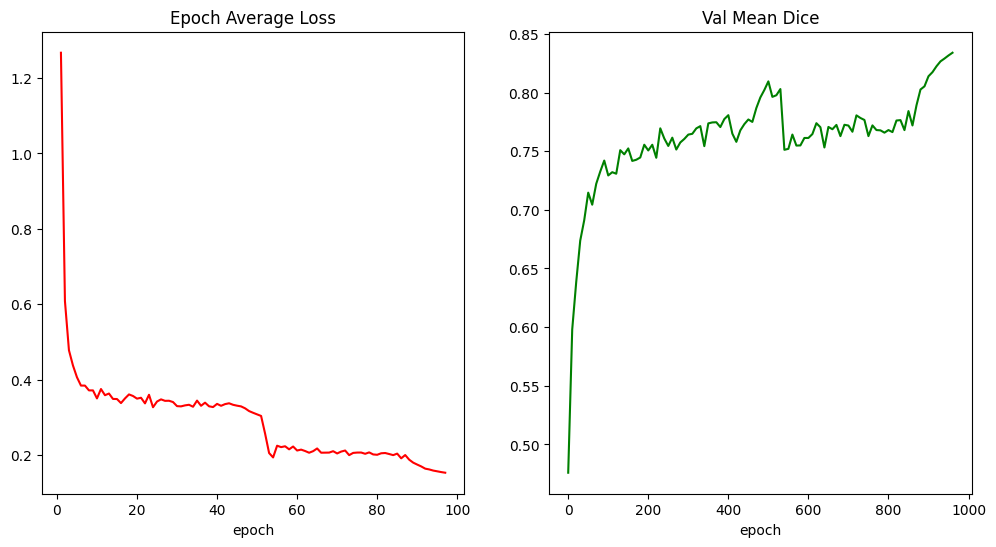

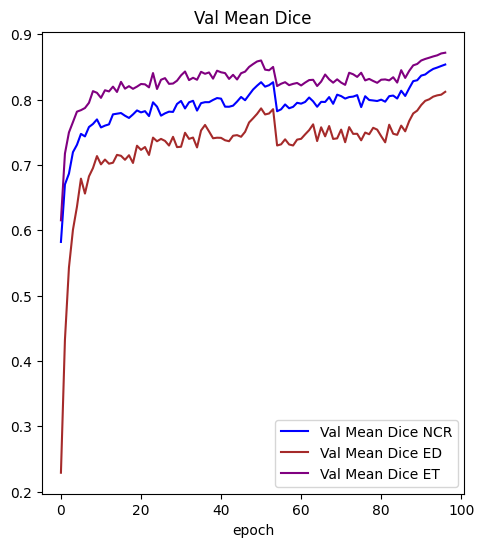

In [ ]:
plt.figure("train", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(net.epoch_loss_values))]
y = net.epoch_loss_values
plt.xlabel("epoch")
plt.plot(x, y, color="red")
plt.subplot(1, 2, 2)
plt.title("Val Mean Dice")
x = [i*10 for i in range(len(net.metric_values))]
y = net.metric_values
plt.xlabel("epoch")
plt.plot(x, y, color="green")
plt.savefig("EpochAverageLoss_ValMeanDice1.png")
plt.show()


plt.figure("train", (12, 6))

plt.subplot(1, 2, 1)
plt.title("Val Mean Dice")
x_ncr = list(range(len(net.metric_values_ncr)))
x_ed = list(range(len(net.metric_values_ed)))
x_et = list(range(len(net.metric_values_et)))

plt.xlabel("epoch")
plt.plot(x_ncr, net.metric_values_ncr, color="blue")
plt.plot(x_ed, net.metric_values_ed, color="brown")
plt.plot(x_et, net.metric_values_et, color="purple")
plt.legend(['Val Mean Dice NCR', 'Val Mean Dice ED', 'Val Mean Dice ET'])

# plt.subplot(1, 2, 2)
# plt.title("Haursdoff Values")
# x_ncr = list(range(len(net.haursdoff_values_ncr)))
# x_ed = list(range(len(net.haursdoff_values_ed)))
# x_et = list(range(len(net.haursdoff_values_et)))

# plt.xlabel("epoch")
# plt.plot(x_ncr, net.haursdoff_values_ncr, color='m')
# plt.plot(x_ed, net.haursdoff_values_ed, color='c')
# plt.plot(x_et, net.haursdoff_values_et, color='k')
# plt.legend(['Haursdoff Values NCR', 'Haursdoff Values ED', 'Haursdoff Values ET'])

# plt.savefig("HaursdoffValuesTC_WT_ET1.png")
# plt.show()

In [ ]:

# Plot the best validation scores
print(f"\nBest Validation Mean Dice: {net.best_val_dice:.4f} ")
print(f"Best WT Dice: {max(net.metric_values_ncr):.4f}")
print(f"Best TC Dice: {max(net.metric_values_ed):.4f}")
print(f"Best ET Dice: {max(net.metric_values_et):.4f}")


Best Validation Mean Dice: 0.8412 
Best WT Dice: 0.8607
Best TC Dice: 0.8208
Best ET Dice: 0.8777


/home/ali/anaconda3/envs/DUT/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.nets.swin_unetr SwinUNETR.__init__:img_size: Argument `img_size` has been deprecated since version 1.3. It will be removed in version 1.5. The img_size argument is not required anymore and checks on the input size are run during forward().
  warn_deprecated(argname, msg, warning_category)


Saved prediction for BraTS-GLI-00000-000 in output


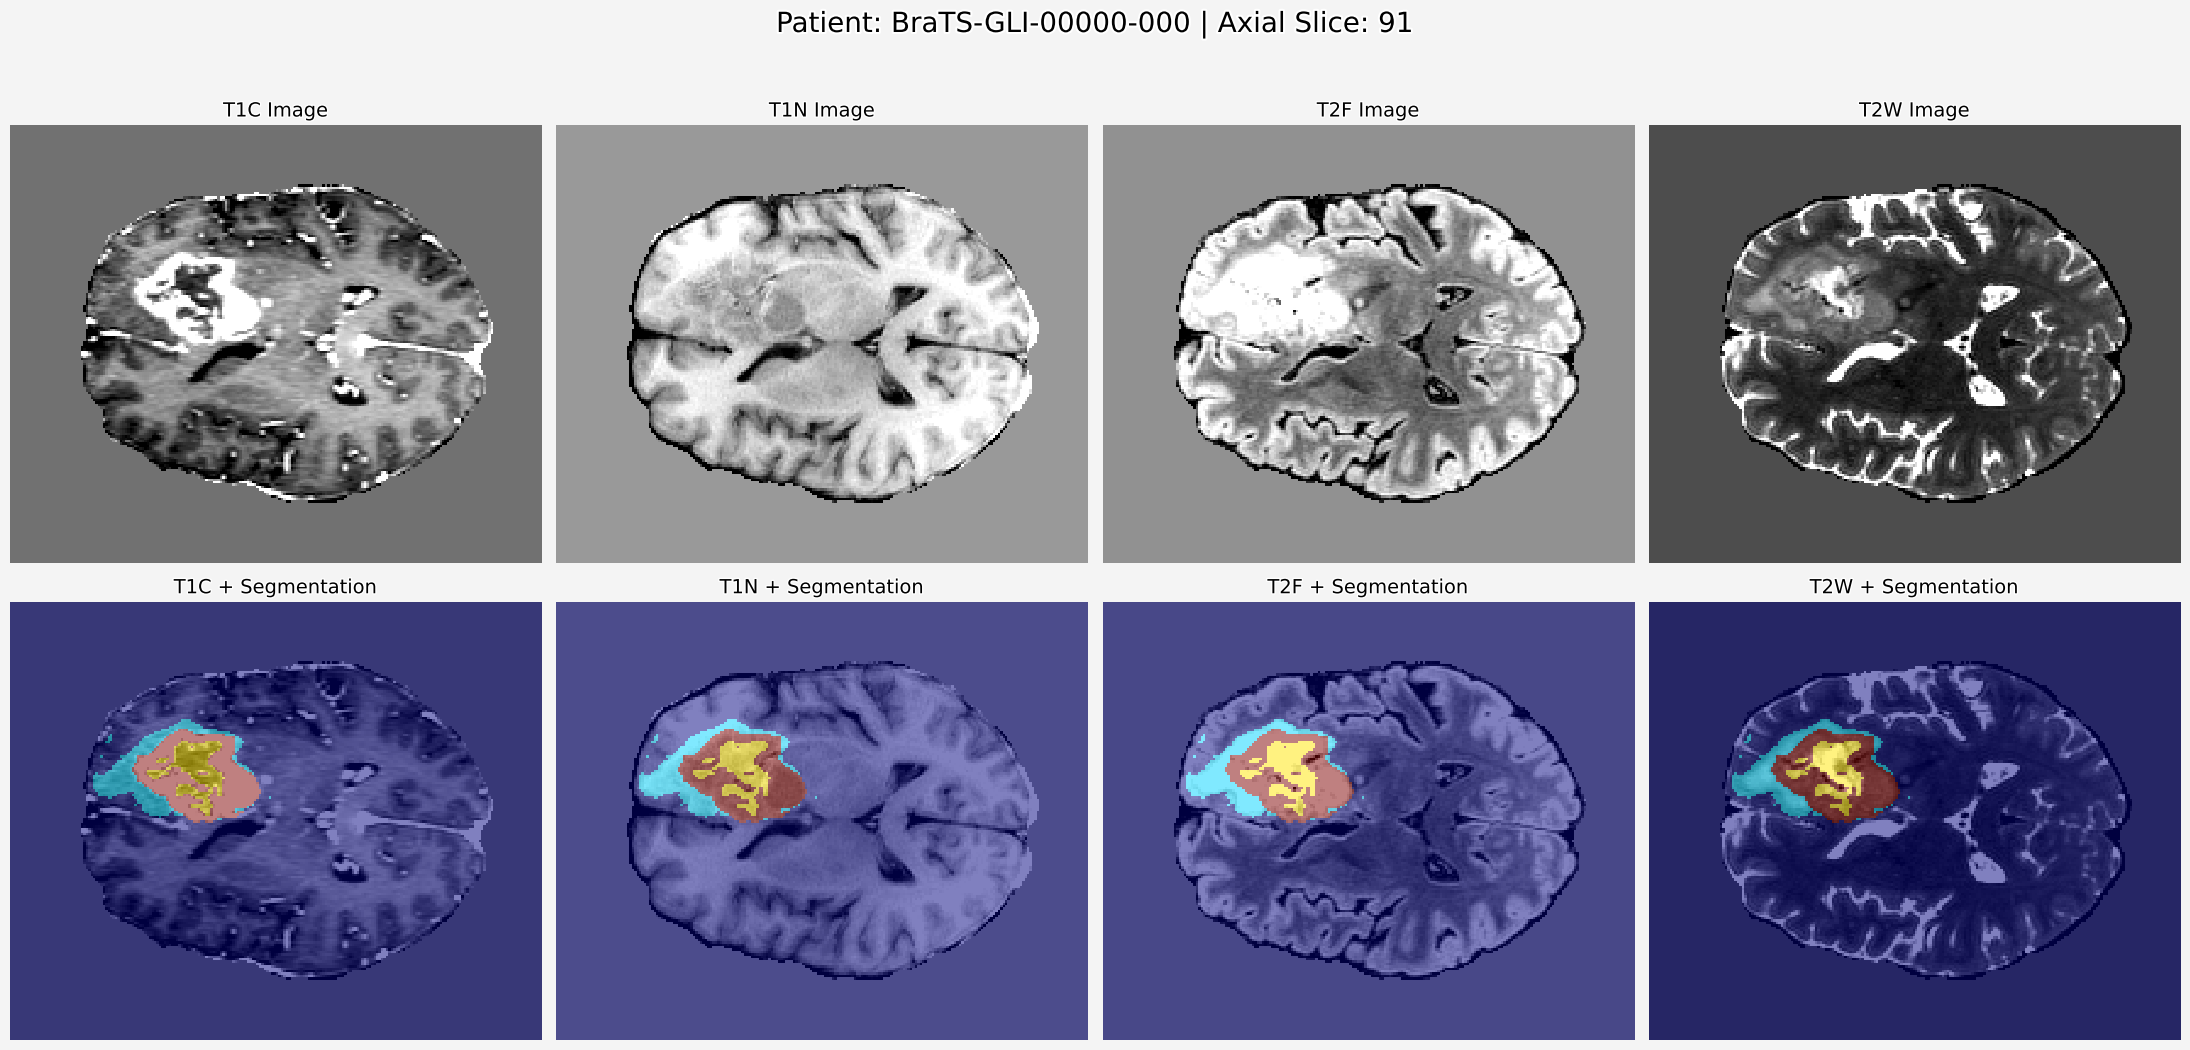

✅ Saved high-quality visualization to: output/BraTS-GLI-00000-000_clear_modalities_prediction.png


In [ ]:
import os
import torch
import numpy as np
import nibabel as nib
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    NormalizeIntensityd, EnsureTyped, AsDiscrete, Activations, MapTransform
)
from monai.inferers import sliding_window_inference
from monai.data import Dataset, DataLoader, decollate_batch
import matplotlib.pyplot as plt

# Custom transform to convert labels into overlapping labels
class ConvertToOverlapLabels(MapTransform):
    def __init__(self, keys):
        super().__init__(keys)

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            label = d[key]
            et_mask = (label == 3)
            tc_mask = (label == 1) | et_mask
            wt_mask = tc_mask | (label == 2)

            new_label = torch.zeros_like(label, dtype=torch.int64)
            new_label[wt_mask] = 1
            new_label[tc_mask] = 2
            new_label[et_mask] = 3

            d[key] = new_label

        return d

# Define the test transforms
test_transform = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    ConvertToOverlapLabels(keys=["label"]),
    EnsureTyped(keys=["image", "label"]),
])

# Post-processing transforms
post_trans = Compose([
    Activations(sigmoid=False, softmax=True),
    AsDiscrete(argmax=True, to_onehot=4),
])



model_ckpt_path = "/home/ali/R_and_D/BTS/Data/Brats2025_dataset/model/best_2024_model.ckpt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

net = Net.load_from_checkpoint(model_ckpt_path)
model = net._model.to(device)
model.eval()


def create_test_data(patient_dir):
    files = {"t1c": None, "t1n": None, "t2f": None, "t2w": None, "seg": None}
    for f in os.listdir(patient_dir):
        if f.endswith(".nii.gz"):
            if "-t1c.nii.gz" in f:
                files["t1c"] = os.path.join(patient_dir, f)
            elif "-t1n.nii.gz" in f:
                files["t1n"] = os.path.join(patient_dir, f)
            elif "-t2f.nii.gz" in f:
                files["t2f"] = os.path.join(patient_dir, f)
            elif "-t2w.nii.gz" in f:
                files["t2w"] = os.path.join(patient_dir, f)
            elif "-seg.nii.gz" in f:
                files["seg"] = os.path.join(patient_dir, f)
    for mod in ["t1c", "t1n", "t2f", "t2w"]:
        if files[mod] is None:
            raise FileNotFoundError(f"Missing {mod} modality in {patient_dir}")
    test_data = {
        "image": [files["t1c"], files["t1n"], files["t2f"], files["t2w"]],
        "label": files["seg"] if files["seg"] else None
    }
    return [test_data]

def infer_patient(patient_dir, output_dir="output"):
    test_files = create_test_data(patient_dir)
    test_ds = Dataset(data=test_files, transform=test_transform)
    test_loader = DataLoader(test_ds, batch_size=1, num_workers=1)
    os.makedirs(output_dir, exist_ok=True)

    with torch.no_grad():
        for test_data in test_loader:
            patient_id = os.path.basename(patient_dir)
            test_images = test_data["image"].to(device)

            # Inference
            roi_size = (96, 96, 96)
            sw_batch_size = 4
            test_outputs = sliding_window_inference(test_images, roi_size, sw_batch_size, model)
            test_outputs = [post_trans(i) for i in decollate_batch(test_outputs)]
            test_outputs = test_outputs[0].cpu().numpy()
            pred_seg = np.argmax(test_outputs, axis=0).astype(np.uint8)

            original_image = test_data["image"][0].cpu().numpy()
            affine = nib.load(test_files[0]["image"][0]).affine

            mod_mapping = {0: "t1c", 1: "t1n", 2: "t2f", 3: "t2w"}
            for i, mod_name in mod_mapping.items():
                mod_img = nib.Nifti1Image(original_image[i], affine)
                nib.save(mod_img, os.path.join(output_dir, f"{patient_id}-{mod_name}.nii.gz"))

            pred_img = nib.Nifti1Image(pred_seg, affine)
            nib.save(pred_img, os.path.join(output_dir, f"{patient_id}_pred_seg.nii.gz"))
            print(f"Saved prediction for {patient_id} in {output_dir}")

            # Save ground truth label if available
            if "label" in test_data:
                label_tensor = test_data["label"]
                if isinstance(label_tensor, torch.Tensor):
                    label_data = label_tensor.cpu().numpy()[0]
                elif isinstance(label_tensor, list):
                    label_data = label_tensor[0].cpu().numpy()
                else:
                    raise ValueError("Unexpected type for label")

                label_data = label_tensor.cpu().numpy()[0].astype(np.uint8)
                label_img = nib.Nifti1Image(label_data, affine)

                nib.save(label_img, os.path.join(output_dir, f"{patient_id}_gt_seg.nii.gz"))

    return pred_seg

import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import os
import numpy as np
import nibabel as nib

def visualize_slices(patient_dir, output_dir="output"):
    import matplotlib.colors as colors

    patient_id = os.path.basename(patient_dir)
    modalities = ["t1c", "t1n", "t2f", "t2w"]
    images = {}

    # Load and normalize all modality images
    def normalize_image(img):
        img = np.clip(img, np.percentile(img, 1), np.percentile(img, 99))  # Contrast stretching
        img = (img - img.min()) / (img.max() - img.min() + 1e-5)
        return img

    for mod in modalities:
        img_path = os.path.join(output_dir, f"{patient_id}-{mod}.nii.gz")
        img = nib.load(img_path).get_fdata()
        images[mod] = normalize_image(img)

    # Load predicted segmentation
    pred_path = os.path.join(output_dir, f"{patient_id}_pred_seg.nii.gz")
    pred = nib.load(pred_path).get_fdata()

    # Use the middle axial slice
    slice_idx = images["t1c"].shape[2] // 2

    fig, axes = plt.subplots(2, 4, figsize=(22, 11), facecolor="#f4f4f4")  # Light background
    axes = axes.ravel()

    def styled_title(ax, title):
        txt = ax.set_title(title, fontsize=14, color='black')
        txt.set_path_effects([path_effects.Stroke(linewidth=2, foreground='white'),
                              path_effects.Normal()])

    for i, mod in enumerate(modalities):
        base_img = images[mod][:, :, slice_idx]
        seg_img = pred[:, :, slice_idx]

        # Top row: raw image
        axes[i].imshow(base_img, cmap="gray", interpolation="nearest", aspect="auto")
        styled_title(axes[i], f"{mod.upper()} Image")
        axes[i].axis("off")
        axes[i].set_frame_on(True)

        # Bottom row: image + prediction
        axes[i + 4].imshow(base_img, cmap="gray", interpolation="nearest", aspect="auto")
        axes[i + 4].imshow(seg_img, alpha=0.5, cmap="jet", interpolation="nearest", aspect="auto")
        styled_title(axes[i + 4], f"{mod.upper()} + Segmentation")
        axes[i + 4].axis("off")
        axes[i + 4].set_frame_on(True)

    suptitle = plt.suptitle(f"Patient: {patient_id} | Axial Slice: {slice_idx}", fontsize=20, color='black')
    suptitle.set_path_effects([path_effects.Stroke(linewidth=3, foreground='white'),
                               path_effects.Normal()])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    vis_path = os.path.join(output_dir, f"{patient_id}_clear_modalities_prediction.png")
    plt.savefig(vis_path, dpi=300, facecolor=fig.get_facecolor())
    plt.show()
    plt.close()
    print(f"✅ Saved high-quality visualization to: {vis_path}")




if __name__ == "__main__":
    patient_directory = "/home/ali/R_and_D/BTS/Data/Brats2025_dataset/BraTS2025-GLI-PRE-Challenge-TrainingData/BraTS-GLI-00000-000"
    pred_seg = infer_patient(patient_directory)
    visualize_slices(patient_directory)


/home/ali/anaconda3/envs/DUT/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.nets.swin_unetr SwinUNETR.__init__:img_size: Argument `img_size` has been deprecated since version 1.3. It will be removed in version 1.5. The img_size argument is not required anymore and checks on the input size are run during forward().
  warn_deprecated(argname, msg, warning_category)


Saved prediction for BraTS-GLI-00000-000 in output


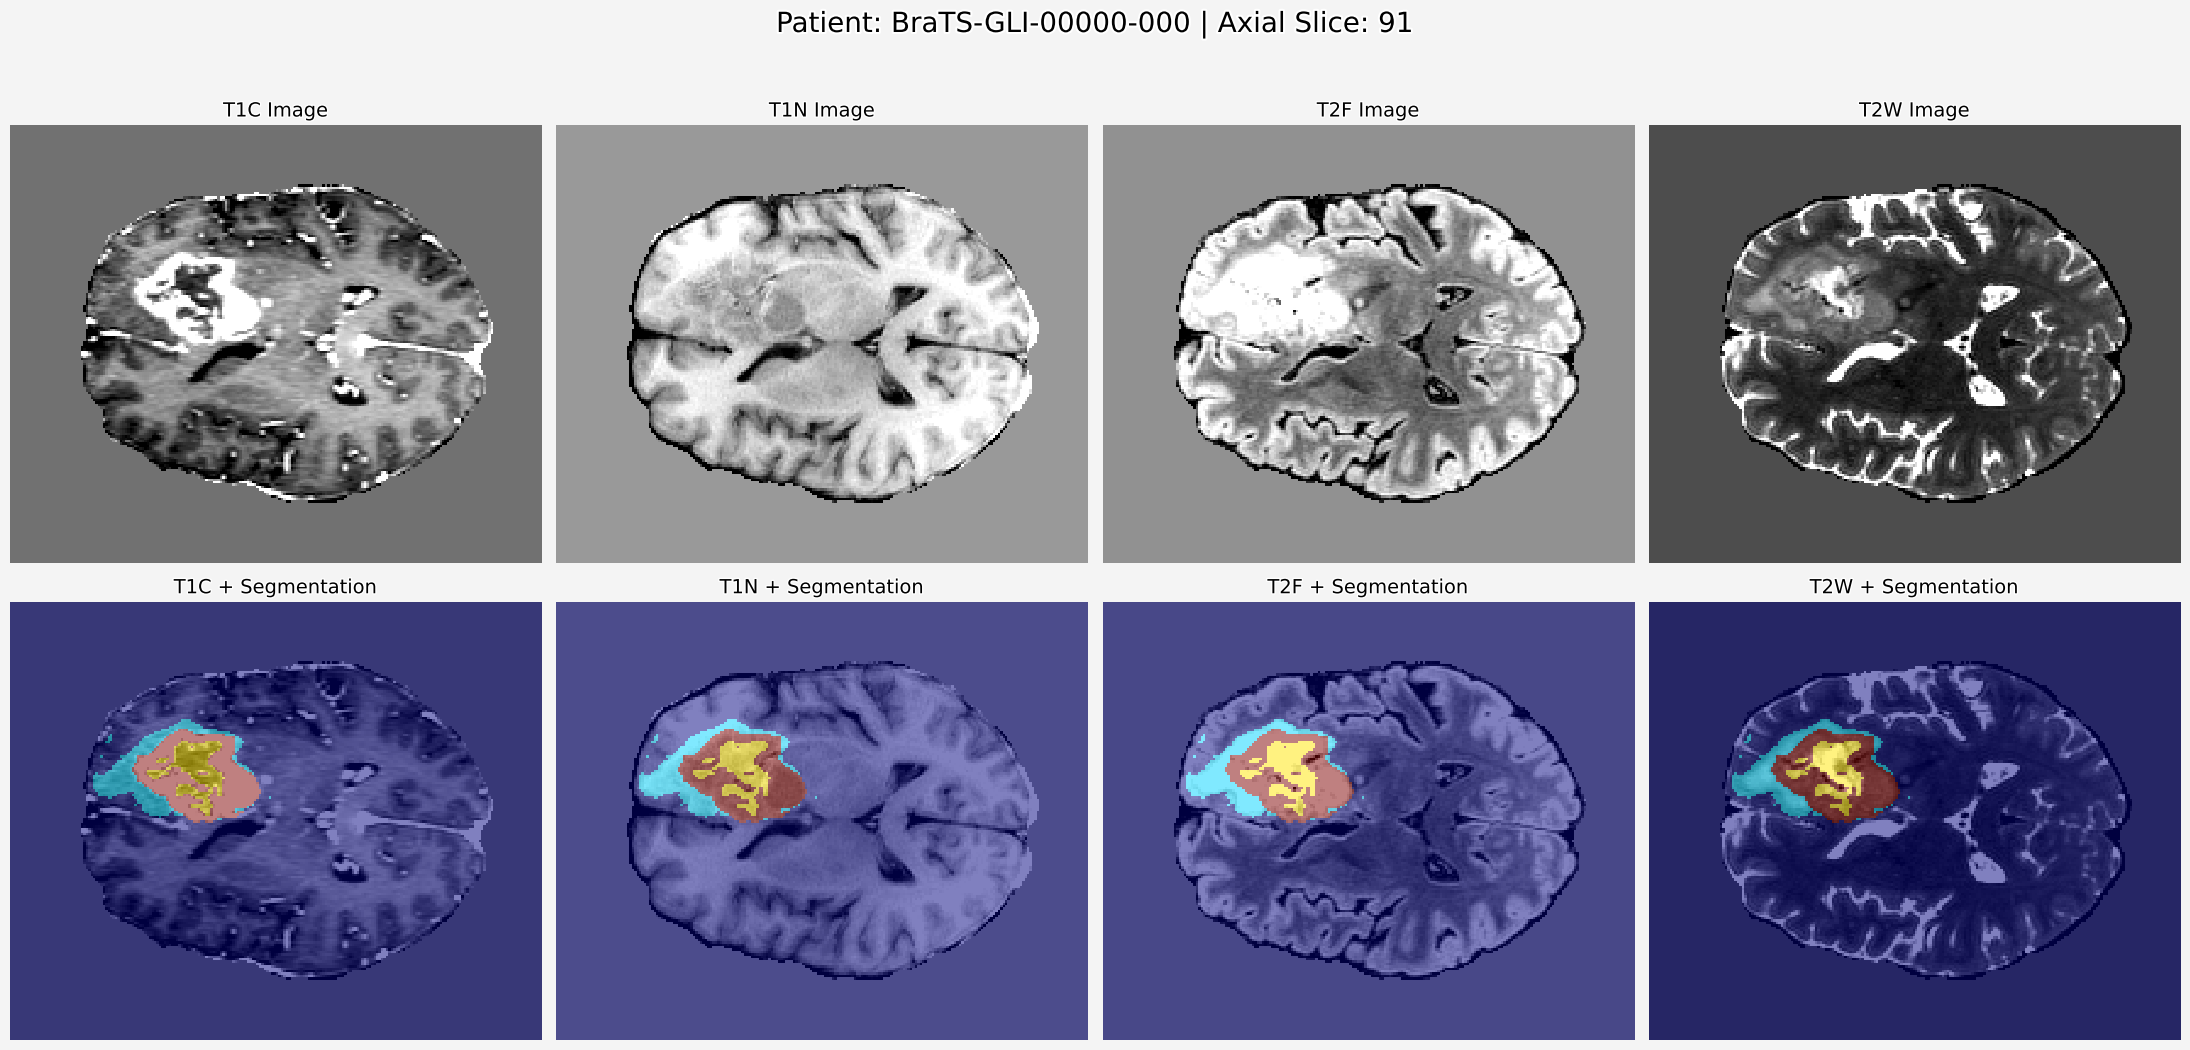

✅ Saved high-quality visualization to: output/BraTS-GLI-00000-000_clear_modalities_prediction.png


In [ ]:
import os
import torch
import numpy as np
import nibabel as nib
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    NormalizeIntensityd, EnsureTyped, AsDiscrete, Activations, MapTransform
)
from monai.inferers import sliding_window_inference
from monai.data import Dataset, DataLoader, decollate_batch
import matplotlib.pyplot as plt

# Custom transform to convert labels into overlapping labels
class ConvertToOverlapLabels(MapTransform):
    def __init__(self, keys):
        super().__init__(keys)

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            label = d[key]
            et_mask = (label == 3)
            tc_mask = (label == 1) | et_mask
            wt_mask = tc_mask | (label == 2)

            new_label = torch.zeros_like(label, dtype=torch.int64)
            new_label[wt_mask] = 1
            new_label[tc_mask] = 2
            new_label[et_mask] = 3

            d[key] = new_label

        return d

# Define the test transforms
test_transform = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    ConvertToOverlapLabels(keys=["label"]),
    EnsureTyped(keys=["image", "label"]),
])

# Post-processing transforms
post_trans = Compose([
    Activations(sigmoid=False, softmax=True),
    AsDiscrete(argmax=True, to_onehot=4),
])



model_ckpt_path = "/home/ali/R_and_D/BTS/Data/Brats2025_dataset/model/best_2024_model.ckpt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

net = Net.load_from_checkpoint(model_ckpt_path)
model = net._model.to(device)
model.eval()


def create_test_data(patient_dir):
    files = {"t1c": None, "t1n": None, "t2f": None, "t2w": None, "seg": None}
    for f in os.listdir(patient_dir):
        if f.endswith(".nii.gz"):
            if "-t1c.nii.gz" in f:
                files["t1c"] = os.path.join(patient_dir, f)
            elif "-t1n.nii.gz" in f:
                files["t1n"] = os.path.join(patient_dir, f)
            elif "-t2f.nii.gz" in f:
                files["t2f"] = os.path.join(patient_dir, f)
            elif "-t2w.nii.gz" in f:
                files["t2w"] = os.path.join(patient_dir, f)
            elif "-seg.nii.gz" in f:
                files["seg"] = os.path.join(patient_dir, f)
    for mod in ["t1c", "t1n", "t2f", "t2w"]:
        if files[mod] is None:
            raise FileNotFoundError(f"Missing {mod} modality in {patient_dir}")
    test_data = {
        "image": [files["t1c"], files["t1n"], files["t2f"], files["t2w"]],
        "label": files["seg"] if files["seg"] else None
    }
    return [test_data]

def infer_patient(patient_dir, output_dir="output"):
    test_files = create_test_data(patient_dir)
    test_ds = Dataset(data=test_files, transform=test_transform)
    test_loader = DataLoader(test_ds, batch_size=1, num_workers=1)
    os.makedirs(output_dir, exist_ok=True)

    with torch.no_grad():
        for test_data in test_loader:
            patient_id = os.path.basename(patient_dir)
            test_images = test_data["image"].to(device)

            # Inference
            roi_size = (96, 96, 96)
            sw_batch_size = 4
            test_outputs = sliding_window_inference(test_images, roi_size, sw_batch_size, model)
            test_outputs = [post_trans(i) for i in decollate_batch(test_outputs)]
            test_outputs = test_outputs[0].cpu().numpy()
            pred_seg = np.argmax(test_outputs, axis=0).astype(np.uint8)

            original_image = test_data["image"][0].cpu().numpy()
            affine = nib.load(test_files[0]["image"][0]).affine

            mod_mapping = {0: "t1c", 1: "t1n", 2: "t2f", 3: "t2w"}
            for i, mod_name in mod_mapping.items():
                mod_img = nib.Nifti1Image(original_image[i], affine)
                nib.save(mod_img, os.path.join(output_dir, f"{patient_id}-{mod_name}.nii.gz"))

            pred_img = nib.Nifti1Image(pred_seg, affine)
            nib.save(pred_img, os.path.join(output_dir, f"{patient_id}_pred_seg.nii.gz"))
            print(f"Saved prediction for {patient_id} in {output_dir}")

            # Save ground truth label if available
            if "label" in test_data:
                label_tensor = test_data["label"]
                if isinstance(label_tensor, torch.Tensor):
                    label_data = label_tensor.cpu().numpy()[0]
                elif isinstance(label_tensor, list):
                    label_data = label_tensor[0].cpu().numpy()
                else:
                    raise ValueError("Unexpected type for label")

                label_data = label_tensor.cpu().numpy()[0].astype(np.uint8)
                label_img = nib.Nifti1Image(label_data, affine)

                nib.save(label_img, os.path.join(output_dir, f"{patient_id}_gt_seg.nii.gz"))

    return pred_seg

import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import os
import numpy as np
import nibabel as nib

def visualize_slices(patient_dir, output_dir="output"):
    import matplotlib.colors as colors

    patient_id = os.path.basename(patient_dir)
    modalities = ["t1c", "t1n", "t2f", "t2w"]
    images = {}

    # Load and normalize all modality images
    def normalize_image(img):
        img = np.clip(img, np.percentile(img, 1), np.percentile(img, 99))  # Contrast stretching
        img = (img - img.min()) / (img.max() - img.min() + 1e-5)
        return img

    for mod in modalities:
        img_path = os.path.join(output_dir, f"{patient_id}-{mod}.nii.gz")
        img = nib.load(img_path).get_fdata()
        images[mod] = normalize_image(img)

    # Load predicted segmentation
    pred_path = os.path.join(output_dir, f"{patient_id}_pred_seg.nii.gz")
    pred = nib.load(pred_path).get_fdata()

    # Use the middle axial slice
    slice_idx = images["t1c"].shape[2] // 2

    fig, axes = plt.subplots(2, 4, figsize=(22, 11), facecolor="#f4f4f4")  # Light background
    axes = axes.ravel()

    def styled_title(ax, title):
        txt = ax.set_title(title, fontsize=14, color='black')
        txt.set_path_effects([path_effects.Stroke(linewidth=2, foreground='white'),
                              path_effects.Normal()])

    for i, mod in enumerate(modalities):
        base_img = images[mod][:, :, slice_idx]
        seg_img = pred[:, :, slice_idx]

        # Top row: raw image
        axes[i].imshow(base_img, cmap="gray", interpolation="nearest", aspect="auto")
        styled_title(axes[i], f"{mod.upper()} Image")
        axes[i].axis("off")
        axes[i].set_frame_on(True)

        # Bottom row: image + prediction
        axes[i + 4].imshow(base_img, cmap="gray", interpolation="nearest", aspect="auto")
        axes[i + 4].imshow(seg_img, alpha=0.5, cmap="jet", interpolation="nearest", aspect="auto")
        styled_title(axes[i + 4], f"{mod.upper()} + Segmentation")
        axes[i + 4].axis("off")
        axes[i + 4].set_frame_on(True)

    suptitle = plt.suptitle(f"Patient: {patient_id} | Axial Slice: {slice_idx}", fontsize=20, color='black')
    suptitle.set_path_effects([path_effects.Stroke(linewidth=3, foreground='white'),
                               path_effects.Normal()])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    vis_path = os.path.join(output_dir, f"{patient_id}_clear_modalities_prediction.png")
    plt.savefig(vis_path, dpi=300, facecolor=fig.get_facecolor())
    plt.show()
    plt.close()
    print(f"✅ Saved high-quality visualization to: {vis_path}")




if __name__ == "__main__":
    patient_directory = "/home/ali/R_and_D/BTS/Data/Brats2025_dataset/BraTS2025-GLI-PRE-Challenge-TrainingData/BraTS-GLI-00000-000"
    pred_seg = infer_patient(patient_directory)
    visualize_slices(patient_directory)


Using device: cuda
Loading model via Lightning checkpoint...


/home/ali/anaconda3/envs/DUT/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.nets.swin_unetr SwinUNETR.__init__:img_size: Argument `img_size` has been deprecated since version 1.3. It will be removed in version 1.5. The img_size argument is not required anymore and checks on the input size are run during forward().
  warn_deprecated(argname, msg, warning_category)


Model loaded successfully!
Preparing validation dataset...
Calculating HD95 metrics...


/home/ali/anaconda3/envs/DUT/lib/python3.11/site-packages/monai/inferers/utils.py:223: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:309.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/home/ali/anaconda3/envs/DUT/lib/python3.11/site-packages/monai/inferers/utils.py:361: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/pyth

Processed batch 1


/home/ali/anaconda3/envs/DUT/lib/python3.11/site-packages/monai/metrics/utils.py:329: UserWarning: the ground truth of class 1 is all 0, this may result in nan/inf distance.
  warnings.warn(
/home/ali/anaconda3/envs/DUT/lib/python3.11/site-packages/monai/metrics/utils.py:329: UserWarning: the ground truth of class 2 is all 0, this may result in nan/inf distance.
  warnings.warn(


Processed batch 11


/home/ali/anaconda3/envs/DUT/lib/python3.11/site-packages/monai/metrics/utils.py:334: UserWarning: the prediction of class 1 is all 0, this may result in nan/inf distance.
  warnings.warn(
/home/ali/anaconda3/envs/DUT/lib/python3.11/site-packages/monai/metrics/utils.py:334: UserWarning: the prediction of class 2 is all 0, this may result in nan/inf distance.
  warnings.warn(


Processed batch 21
Processed batch 31
Processed batch 41
Processed batch 51
Processed batch 61

HD95 METRICS RESULTS
Mean HD95: 5.6681 mm
WT HD95: 7.7217 mm
TC HD95: 5.0486 mm
ET HD95: 4.2342 mm
Generating plots...


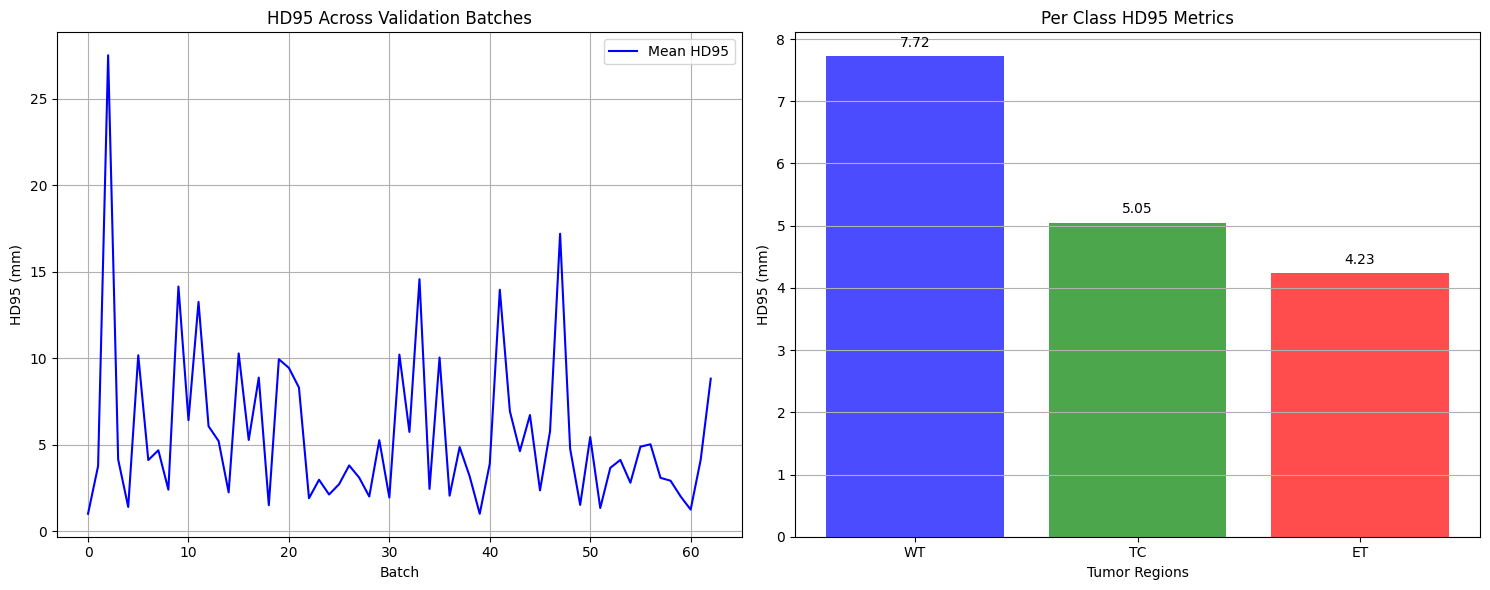

Results saved to hd95_metrics_results.json


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import json
from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.transforms import (
    AsDiscrete, Compose, LoadImaged, EnsureChannelFirstd,
    Orientationd, Spacingd, NormalizeIntensityd
)
from monai.inferers import sliding_window_inference
from monai.data import DataLoader, decollate_batch, load_decathlon_datalist
import monai.data
from monai.networks.nets import SwinUNETR
from monai.losses import DiceCELoss
import torch.nn as nn
import pytorch_lightning as pl
from sklearn.model_selection import train_test_split

# Define your Net class with all required imports
class ConvertToOverlapLabels:
    def __init__(self, keys):
        self.keys = keys

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            label = d[key]
            et_mask = (label == 3)
            tc_mask = (label == 1) | et_mask
            wt_mask = tc_mask | (label == 2)

            new_label = torch.zeros_like(label, dtype=torch.int64)
            new_label[wt_mask] = 1
            new_label[tc_mask] = 2
            new_label[et_mask] = 3

            d[key] = new_label
        return d

class Expert(nn.Module):
    def __init__(self, img_size=(96, 96, 96), in_channels=4, out_channels=4):
        super().__init__()
        self.model = SwinUNETR(
            img_size=img_size,
            in_channels=in_channels,
            out_channels=out_channels,
            feature_size=48,
            use_checkpoint=True,
        )

    def forward(self, x):
        return self.model(x)

class GatingNetwork(nn.Module):
    def __init__(self, num_experts=3, in_channels=4, hidden_dim=64):
        super().__init__()
        self.num_experts = num_experts
        self.feature_extractor = nn.Sequential(
            nn.Conv3d(in_channels, hidden_dim, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool3d(1),
            nn.Flatten()
        )
        self.gate = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_experts),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.gate(features)

class MoE_SWINUNETR(nn.Module):
    def __init__(self, num_experts=3, img_size=(96, 96, 96), in_channels=4, out_channels=4):
        super().__init__()
        self.num_experts = num_experts
        self.img_size = img_size
        self.experts = nn.ModuleList([Expert(img_size, in_channels, out_channels) for _ in range(num_experts)])
        self.gate = GatingNetwork(num_experts, in_channels)
        self.final_conv = nn.Conv3d(out_channels * num_experts, out_channels, kernel_size=1)

    def forward(self, x):
        gate_weights = self.gate(x)
        expert_outputs = []
        for i, expert in enumerate(self.experts):
            expert_out = expert(x)
            expert_outputs.append(expert_out * gate_weights[:, i].view(-1, 1, 1, 1, 1))
        combined = torch.cat(expert_outputs, dim=1)
        output = self.final_conv(combined)
        return output

class Net(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self._model = MoE_SWINUNETR(num_experts=3, img_size=(96, 96, 96), in_channels=4, out_channels=4)
        self.loss_function = DiceCELoss(to_onehot_y=True, softmax=True)
        self.post_pred = AsDiscrete(argmax=True, to_onehot=4)
        self.post_label = AsDiscrete(to_onehot=4)
        self.dice_metric = DiceMetric(include_background=False, reduction="mean")
        self.dice_metric_batch = DiceMetric(include_background=False, reduction="mean_batch")
        self.check_val = 1
        self.best_val_dice = 0
        self.best_val_epoch = 0

    def forward(self, x):
        return self._model(x)

    def prepare_data(self):
        datasets = "/home/ali/R_and_D/BTS/Data/Brats2025_dataset/preprocessed_2025_dataset.json"
        datalist = load_decathlon_datalist(datasets, True, "training")
        _, val_files = train_test_split(datalist, test_size=0.1, random_state=42)
        self.val_files = val_files

    def val_dataloader(self):
        val_transform = Compose([
            LoadImaged(keys=["image", "label"]),
            EnsureChannelFirstd(keys=["image", "label"]),
            Orientationd(keys=["image", "label"], axcodes="RAS"),
            ConvertToOverlapLabels(keys=["label"]),
            Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
            NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
        ])
        val_ds = monai.data.Dataset(data=self.val_files, transform=val_transform)
        return DataLoader(val_ds, batch_size=2, shuffle=False, num_workers=4)

# HD95 Metric Calculation
def calculate_hd95_metrics(model, val_loader, device):
    hd95_metric = HausdorffDistanceMetric(
        include_background=False,
        distance_metric='euclidean',
        percentile=95,
        reduction="mean_batch"
    )

    post_pred = AsDiscrete(argmax=True, to_onehot=4)
    post_label = AsDiscrete(to_onehot=4)

    all_hd95_values = []
    hd95_per_class = {'WT': [], 'TC': [], 'ET': []}

    with torch.no_grad():
        for batch_idx, batch in enumerate(val_loader):
            images, labels = batch["image"].to(device), batch["label"].to(device)

            roi_size, sw_batch_size = (96, 96, 96), 4
            outputs = sliding_window_inference(images, roi_size, sw_batch_size, model)

            outputs = [post_pred(i) for i in decollate_batch(outputs)]
            labels = [post_label(i) for i in decollate_batch(labels)]

            hd95_metric(y_pred=outputs, y=labels)
            hd95_batch = hd95_metric.aggregate()

            if hd95_batch.numel() > 0:
                all_hd95_values.append(hd95_batch.mean().item())
                if len(hd95_batch) >= 3:
                    hd95_per_class['WT'].append(hd95_batch[0].item())
                    hd95_per_class['TC'].append(hd95_batch[1].item())
                    hd95_per_class['ET'].append(hd95_batch[2].item())

            hd95_metric.reset()

            if batch_idx % 10 == 0:
                print(f"Processed batch {batch_idx + 1}")

    mean_hd95 = np.mean(all_hd95_values) if all_hd95_values else float('nan')
    mean_wt_hd95 = np.mean(hd95_per_class['WT']) if hd95_per_class['WT'] else float('nan')
    mean_tc_hd95 = np.mean(hd95_per_class['TC']) if hd95_per_class['TC'] else float('nan')
    mean_et_hd95 = np.mean(hd95_per_class['ET']) if hd95_per_class['ET'] else float('nan')

    return {
        'mean_hd95': mean_hd95,
        'wt_hd95': mean_wt_hd95,
        'tc_hd95': mean_tc_hd95,
        'et_hd95': mean_et_hd95,
        'all_hd95': all_hd95_values,
        'per_class_hd95': hd95_per_class
    }

# Plot HD95 results
def plot_hd95_results(hd95_results):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Plot 1: Mean HD95 across batches
    if hd95_results['all_hd95']:
        ax1.plot(hd95_results['all_hd95'], 'b-', label='Mean HD95')
        ax1.set_xlabel('Batch')
        ax1.set_ylabel('HD95 (mm)')
        ax1.set_title('HD95 Across Validation Batches')
        ax1.grid(True)
        ax1.legend()

    # Plot 2: Per class HD95
    classes = ['WT', 'TC', 'ET']
    class_hd95 = [hd95_results['wt_hd95'], hd95_results['tc_hd95'], hd95_results['et_hd95']]

    if not all(np.isnan(val) for val in class_hd95):
        bars = ax2.bar(classes, class_hd95, color=['blue', 'green', 'red'], alpha=0.7)
        ax2.set_xlabel('Tumor Regions')
        ax2.set_ylabel('HD95 (mm)')
        ax2.set_title('Per Class HD95 Metrics')
        ax2.grid(True, axis='y')

        for bar, value in zip(bars, class_hd95):
            if not np.isnan(value):
                ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                        f'{value:.2f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig('hd95_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()

    return fig

# Main execution
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Load via Lightning checkpoint
    model_ckpt_path = "/home/ali/R_and_D/BTS/Data/Brats2025_dataset/model/best_2024_model.ckpt"

    print("Loading model via Lightning checkpoint...")
    net = Net.load_from_checkpoint(model_ckpt_path)
    model = net._model.to(device)
    model.eval()
    print("Model loaded successfully!")

    # Prepare data
    print("Preparing validation dataset...")
    net.prepare_data()
    val_loader = net.val_dataloader()

    # Calculate HD95 metrics
    print("Calculating HD95 metrics...")
    hd95_results = calculate_hd95_metrics(model, val_loader, device)

    # Print results
    print("\n" + "="*50)
    print("HD95 METRICS RESULTS")
    print("="*50)
    print(f"Mean HD95: {hd95_results['mean_hd95']:.4f} mm")
    print(f"WT HD95: {hd95_results['wt_hd95']:.4f} mm")
    print(f"TC HD95: {hd95_results['tc_hd95']:.4f} mm")
    print(f"ET HD95: {hd95_results['et_hd95']:.4f} mm")
    print("="*50)

    # Plot results
    print("Generating plots...")
    plot_hd95_results(hd95_results)

    # Save results
    with open('hd95_metrics_results.json', 'w') as f:
        json.dump({k: v for k, v in hd95_results.items() if k in ['mean_hd95', 'wt_hd95', 'tc_hd95', 'et_hd95']},
                 f, indent=4)
    print("Results saved to hd95_metrics_results.json")

✅ Saved prediction for BraTS-GLI-00000-000 in output


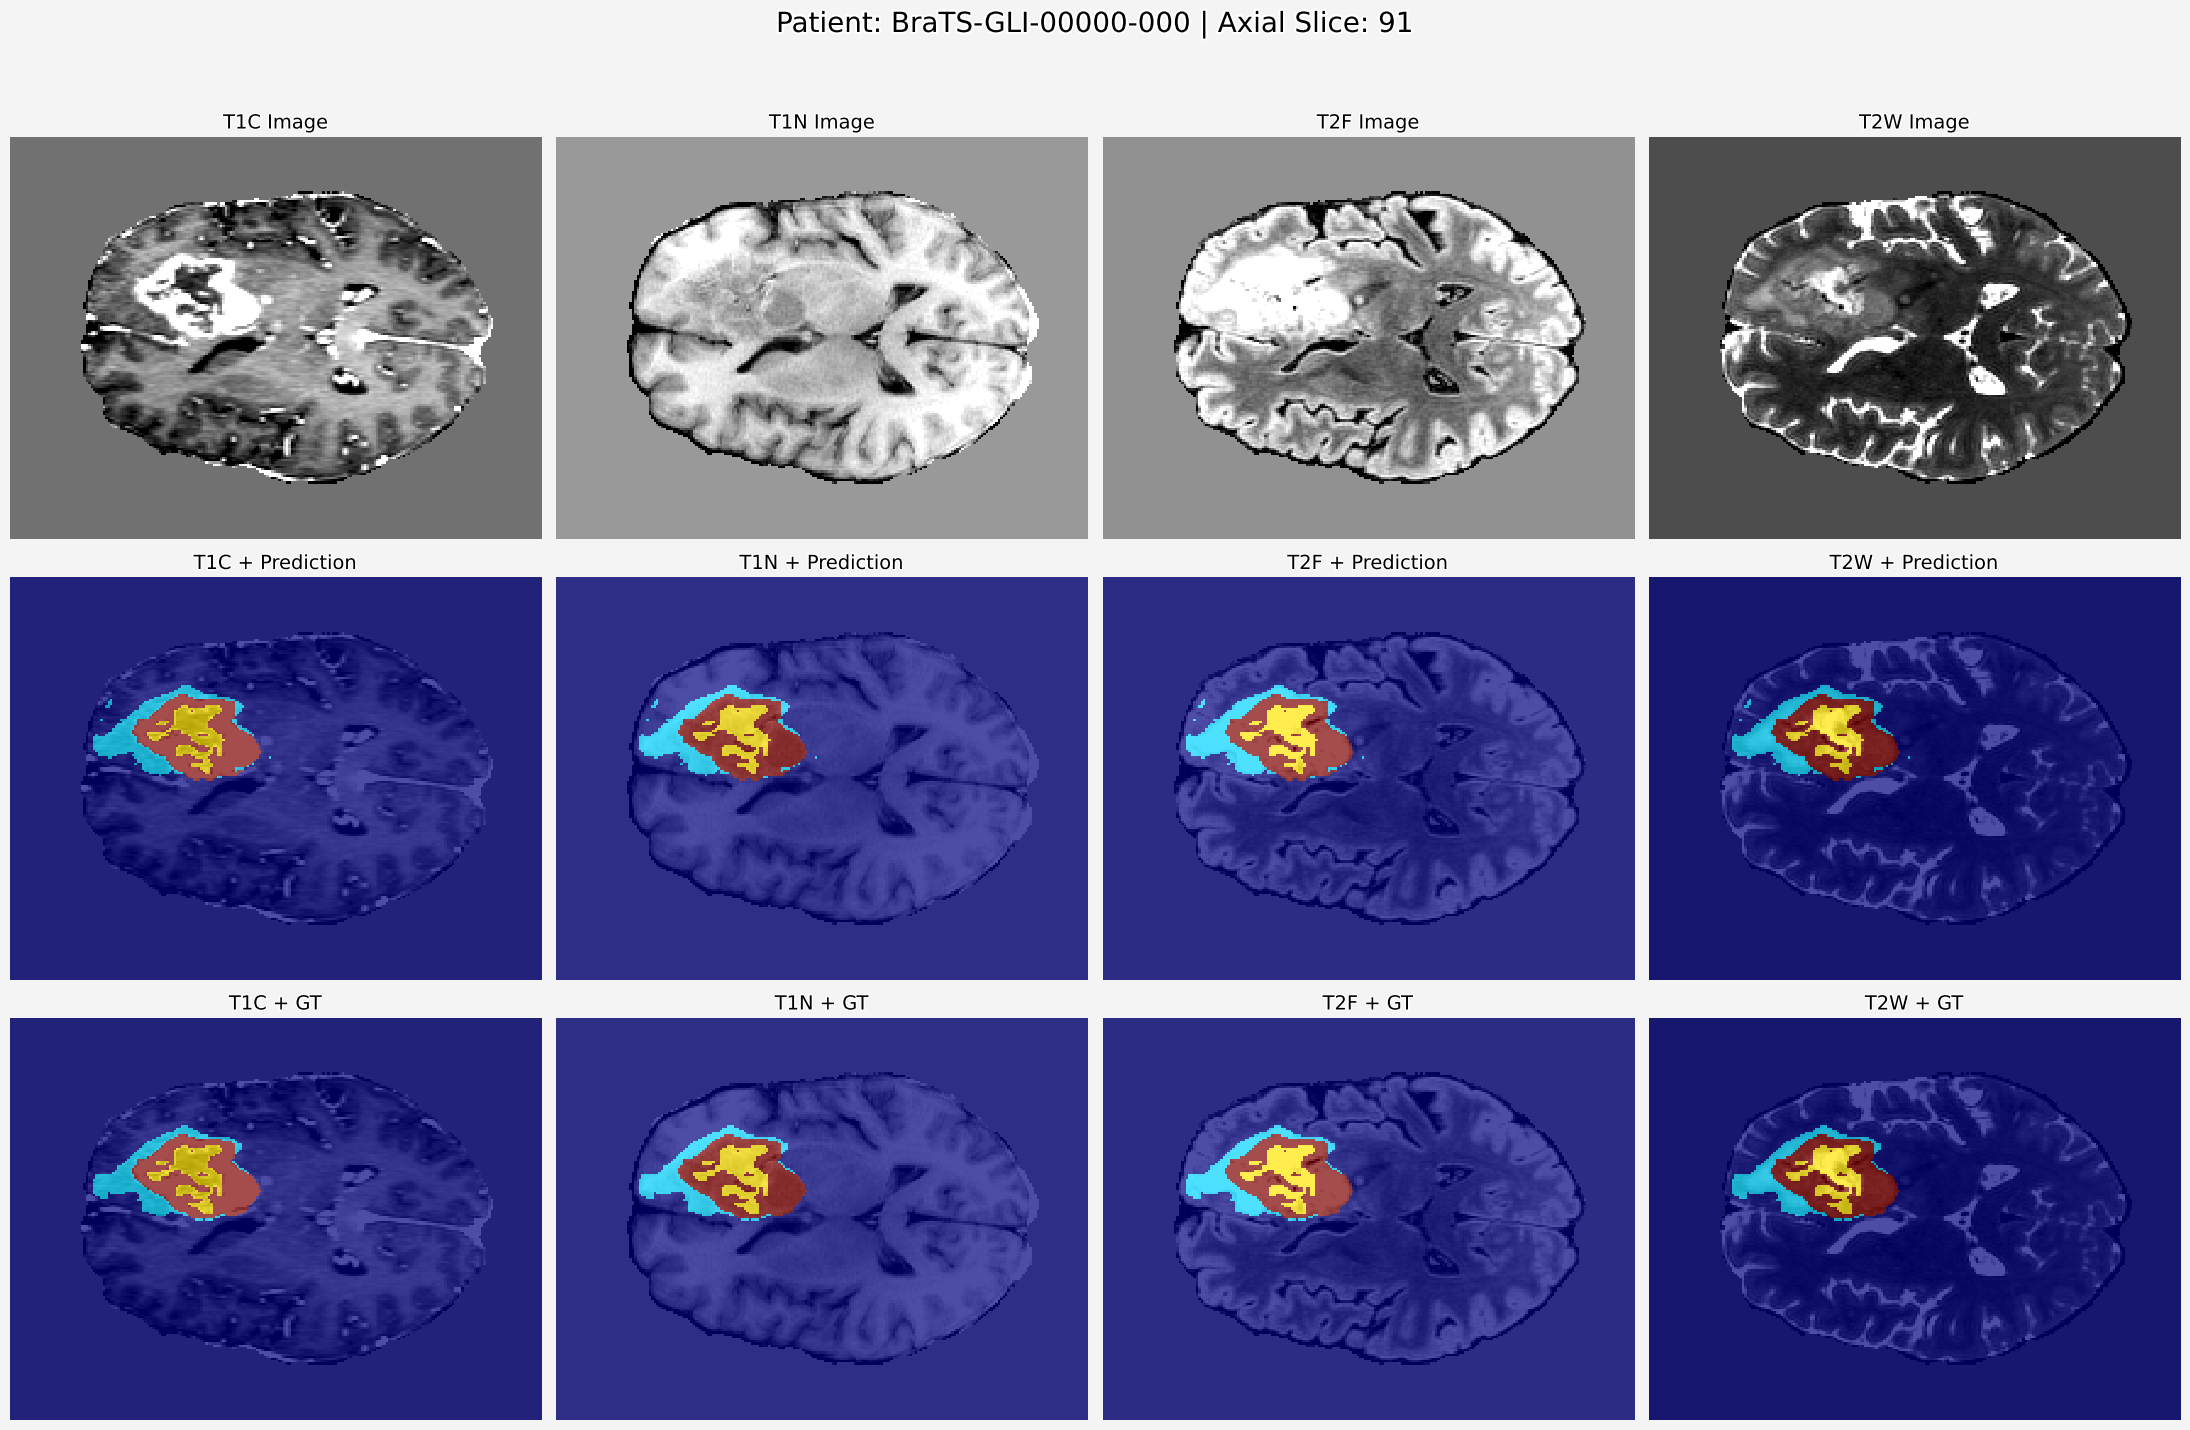

✅ Saved high-quality visualization to: output/BraTS-GLI-00000-000_clear_modalities_prediction.png


In [ ]:
import os
import torch
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    NormalizeIntensityd, EnsureTyped, AsDiscrete, Activations, MapTransform
)
from monai.inferers import sliding_window_inference
from monai.data import Dataset, DataLoader, decollate_batch

# =========================
# Custom transform to convert labels into overlapping labels
# =========================
class ConvertToOverlapLabels(MapTransform):
    def __init__(self, keys):
        super().__init__(keys)

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            label = d[key]
            et_mask = (label == 3)
            tc_mask = (label == 1) | et_mask
            wt_mask = tc_mask | (label == 2)

            new_label = torch.zeros_like(label, dtype=torch.int64)
            new_label[wt_mask] = 1
            new_label[tc_mask] = 2
            new_label[et_mask] = 3

            d[key] = new_label
        return d

# =========================
# Define the test transforms
# =========================
test_transform = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    ConvertToOverlapLabels(keys=["label"]),
    EnsureTyped(keys=["image", "label"]),
])

# =========================
# Post-processing transforms
# =========================
post_trans = Compose([
    Activations(sigmoid=False, softmax=True),
    AsDiscrete(argmax=True, to_onehot=4),
])

# =========================
# Load model checkpoint
# =========================
model_ckpt_path = "/home/ali/R_and_D/BTS/Data/Brats2025_dataset/model/best_2024_model.ckpt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

net = Net.load_from_checkpoint(model_ckpt_path)
model = net._model.to(device)
model.eval()

# =========================
# Create test data dictionary
# =========================
def create_test_data(patient_dir):
    patient_id = os.path.basename(patient_dir)
    expected_files = {
        "t1c": f"{patient_id}-t1c.nii.gz",
        "t1n": f"{patient_id}-t1n.nii.gz",
        "t2f": f"{patient_id}-t2f.nii.gz",
        "t2w": f"{patient_id}-t2w.nii.gz",
        "seg": f"{patient_id}-seg.nii.gz"
    }

    files = {}
    for key, fname in expected_files.items():
        fpath = os.path.join(patient_dir, fname)
        if os.path.exists(fpath):
            files[key] = fpath
        else:
            if key != "seg":  # seg might be missing in test set
                raise FileNotFoundError(f"Missing required modality: {fpath}")

    return [{
        "image": [files["t1c"], files["t1n"], files["t2f"], files["t2w"]],
        "label": files.get("seg", None)
    }]

# =========================
# Inference function
# =========================
def infer_patient(patient_dir, output_dir="output"):
    test_files = create_test_data(patient_dir)
    test_ds = Dataset(data=test_files, transform=test_transform)
    test_loader = DataLoader(test_ds, batch_size=1, num_workers=1)
    os.makedirs(output_dir, exist_ok=True)

    pred_seg = None
    with torch.no_grad():
        for test_data in test_loader:
            patient_id = os.path.basename(patient_dir)
            test_images = test_data["image"].to(device)

            roi_size = (96, 96, 96)
            sw_batch_size = 4
            test_outputs = sliding_window_inference(test_images, roi_size, sw_batch_size, model)
            test_outputs = [post_trans(i) for i in decollate_batch(test_outputs)]
            test_outputs = test_outputs[0].cpu().numpy()
            pred_seg = np.argmax(test_outputs, axis=0).astype(np.uint8)

            original_image = test_data["image"][0].cpu().numpy()
            affine = nib.load(test_files[0]["image"][0]).affine

            # Save modalities
            mod_mapping = {0: "t1c", 1: "t1n", 2: "t2f", 3: "t2w"}
            for i, mod_name in mod_mapping.items():
                mod_img = nib.Nifti1Image(original_image[i], affine)
                nib.save(mod_img, os.path.join(output_dir, f"{patient_id}-{mod_name}.nii.gz"))

            # Save prediction
            pred_img = nib.Nifti1Image(pred_seg, affine)
            nib.save(pred_img, os.path.join(output_dir, f"{patient_id}_pred_seg.nii.gz"))
            print(f"✅ Saved prediction for {patient_id} in {output_dir}")

            # Save ground truth
            if "label" in test_data and test_data["label"] is not None:
                label_tensor = test_data["label"]
                label_data = label_tensor.cpu().numpy()[0].astype(np.uint8)
                label_img = nib.Nifti1Image(label_data, affine)
                nib.save(label_img, os.path.join(output_dir, f"{patient_id}_gt_seg.nii.gz"))
    return pred_seg

# =========================
# Visualization function
# =========================
def visualize_slices(patient_dir, output_dir="output"):
    import matplotlib.colors as colors

    patient_id = os.path.basename(patient_dir)
    modalities = ["t1c", "t1n", "t2f", "t2w"]
    images = {}

    def normalize_image(img):
        img = np.clip(img, np.percentile(img, 1), np.percentile(img, 99))
        img = (img - img.min()) / (img.max() - img.min() + 1e-5)
        return img

    # === Load & squeeze all modalities ===
    for mod in modalities:
        img_path = os.path.join(output_dir, f"{patient_id}-{mod}.nii.gz")
        img = nib.load(img_path).get_fdata()
        if img.ndim == 4 and img.shape[0] == 1:  # remove channel dim if exists
            img = np.squeeze(img, axis=0)
        images[mod] = normalize_image(img)

    # === Load prediction ===
    pred_path = os.path.join(output_dir, f"{patient_id}_pred_seg.nii.gz")
    pred = nib.load(pred_path).get_fdata()
    if pred.ndim == 4 and pred.shape[0] == 1:
        pred = np.squeeze(pred, axis=0)

    # === Load GT if exists ===
    gt = None
    gt_path = os.path.join(output_dir, f"{patient_id}_gt_seg.nii.gz")
    if os.path.exists(gt_path):
        gt = nib.load(gt_path).get_fdata()
        if gt.ndim == 4 and gt.shape[0] == 1:
            gt = np.squeeze(gt, axis=0)

    slice_idx = images["t1c"].shape[2] // 2

    # --- Create 3-row grid (Images | Prediction | GT) ---
    n_rows = 3 if gt is not None else 2
    fig, axes = plt.subplots(n_rows, 4, figsize=(22, 15 if gt is not None else 11), facecolor="#f4f4f4")
    axes = axes.ravel()

    def styled_title(ax, title):
        txt = ax.set_title(title, fontsize=14, color='black')
        txt.set_path_effects([path_effects.Stroke(linewidth=2, foreground='white'),
                              path_effects.Normal()])

    for i, mod in enumerate(modalities):
        base_img = images[mod][:, :, slice_idx]

        # Row 1: raw modality
        axes[i].imshow(base_img, cmap="gray", interpolation="nearest", aspect="auto")
        styled_title(axes[i], f"{mod.upper()} Image")
        axes[i].axis("off")
        axes[i].set_frame_on(True)

        # Row 2: prediction overlay
        seg_img = pred[:, :, slice_idx]
        axes[i + 4].imshow(base_img, cmap="gray", interpolation="nearest", aspect="auto")
        axes[i + 4].imshow(seg_img, alpha=0.7, cmap="jet", interpolation="nearest", aspect="auto")
        styled_title(axes[i + 4], f"{mod.upper()} + Prediction")
        axes[i + 4].axis("off")
        axes[i + 4].set_frame_on(True)

        # Row 3: ground truth overlay (if available)
        if gt is not None:
            gt_img = gt[:, :, slice_idx]
            axes[i + 8].imshow(base_img, cmap="gray", interpolation="nearest", aspect="auto")
            axes[i + 8].imshow(gt_img, alpha=0.7, cmap="jet", interpolation="nearest", aspect="auto")
            styled_title(axes[i + 8], f"{mod.upper()} + GT")
            axes[i + 8].axis("off")
            axes[i + 8].set_frame_on(True)

    suptitle = plt.suptitle(f"Patient: {patient_id} | Axial Slice: {slice_idx}", fontsize=20, color='black')
    suptitle.set_path_effects([path_effects.Stroke(linewidth=3, foreground='white'),
                               path_effects.Normal()])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    vis_path = os.path.join(output_dir, f"{patient_id}_clear_modalities_prediction.png")
    plt.savefig(vis_path, dpi=300, facecolor=fig.get_facecolor())
    plt.show()
    plt.close()
    print(f"✅ Saved high-quality visualization to: {vis_path}")

# =========================
# Main Execution
# =========================
if __name__ == "__main__":
    patient_directory = "/home/ali/R_and_D/BTS/Data/Brats2025_dataset/BraTS2025-GLI-PRE-Challenge-TrainingData/BraTS-GLI-00000-000"
    pred_seg = infer_patient(patient_directory)
    visualize_slices(patient_directory)


/home/ali/anaconda3/envs/DUT/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.nets.swin_unetr SwinUNETR.__init__:img_size: Argument `img_size` has been deprecated since version 1.3. It will be removed in version 1.5. The img_size argument is not required anymore and checks on the input size are run during forward().
  warn_deprecated(argname, msg, warning_category)
/home/ali/anaconda3/envs/DUT/lib/python3.11/site-packages/monai/inferers/utils.py:223: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:309.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/home/ali/anaconda3/envs/D

✅ Saved prediction for BraTS-GLI-00000-000 in output


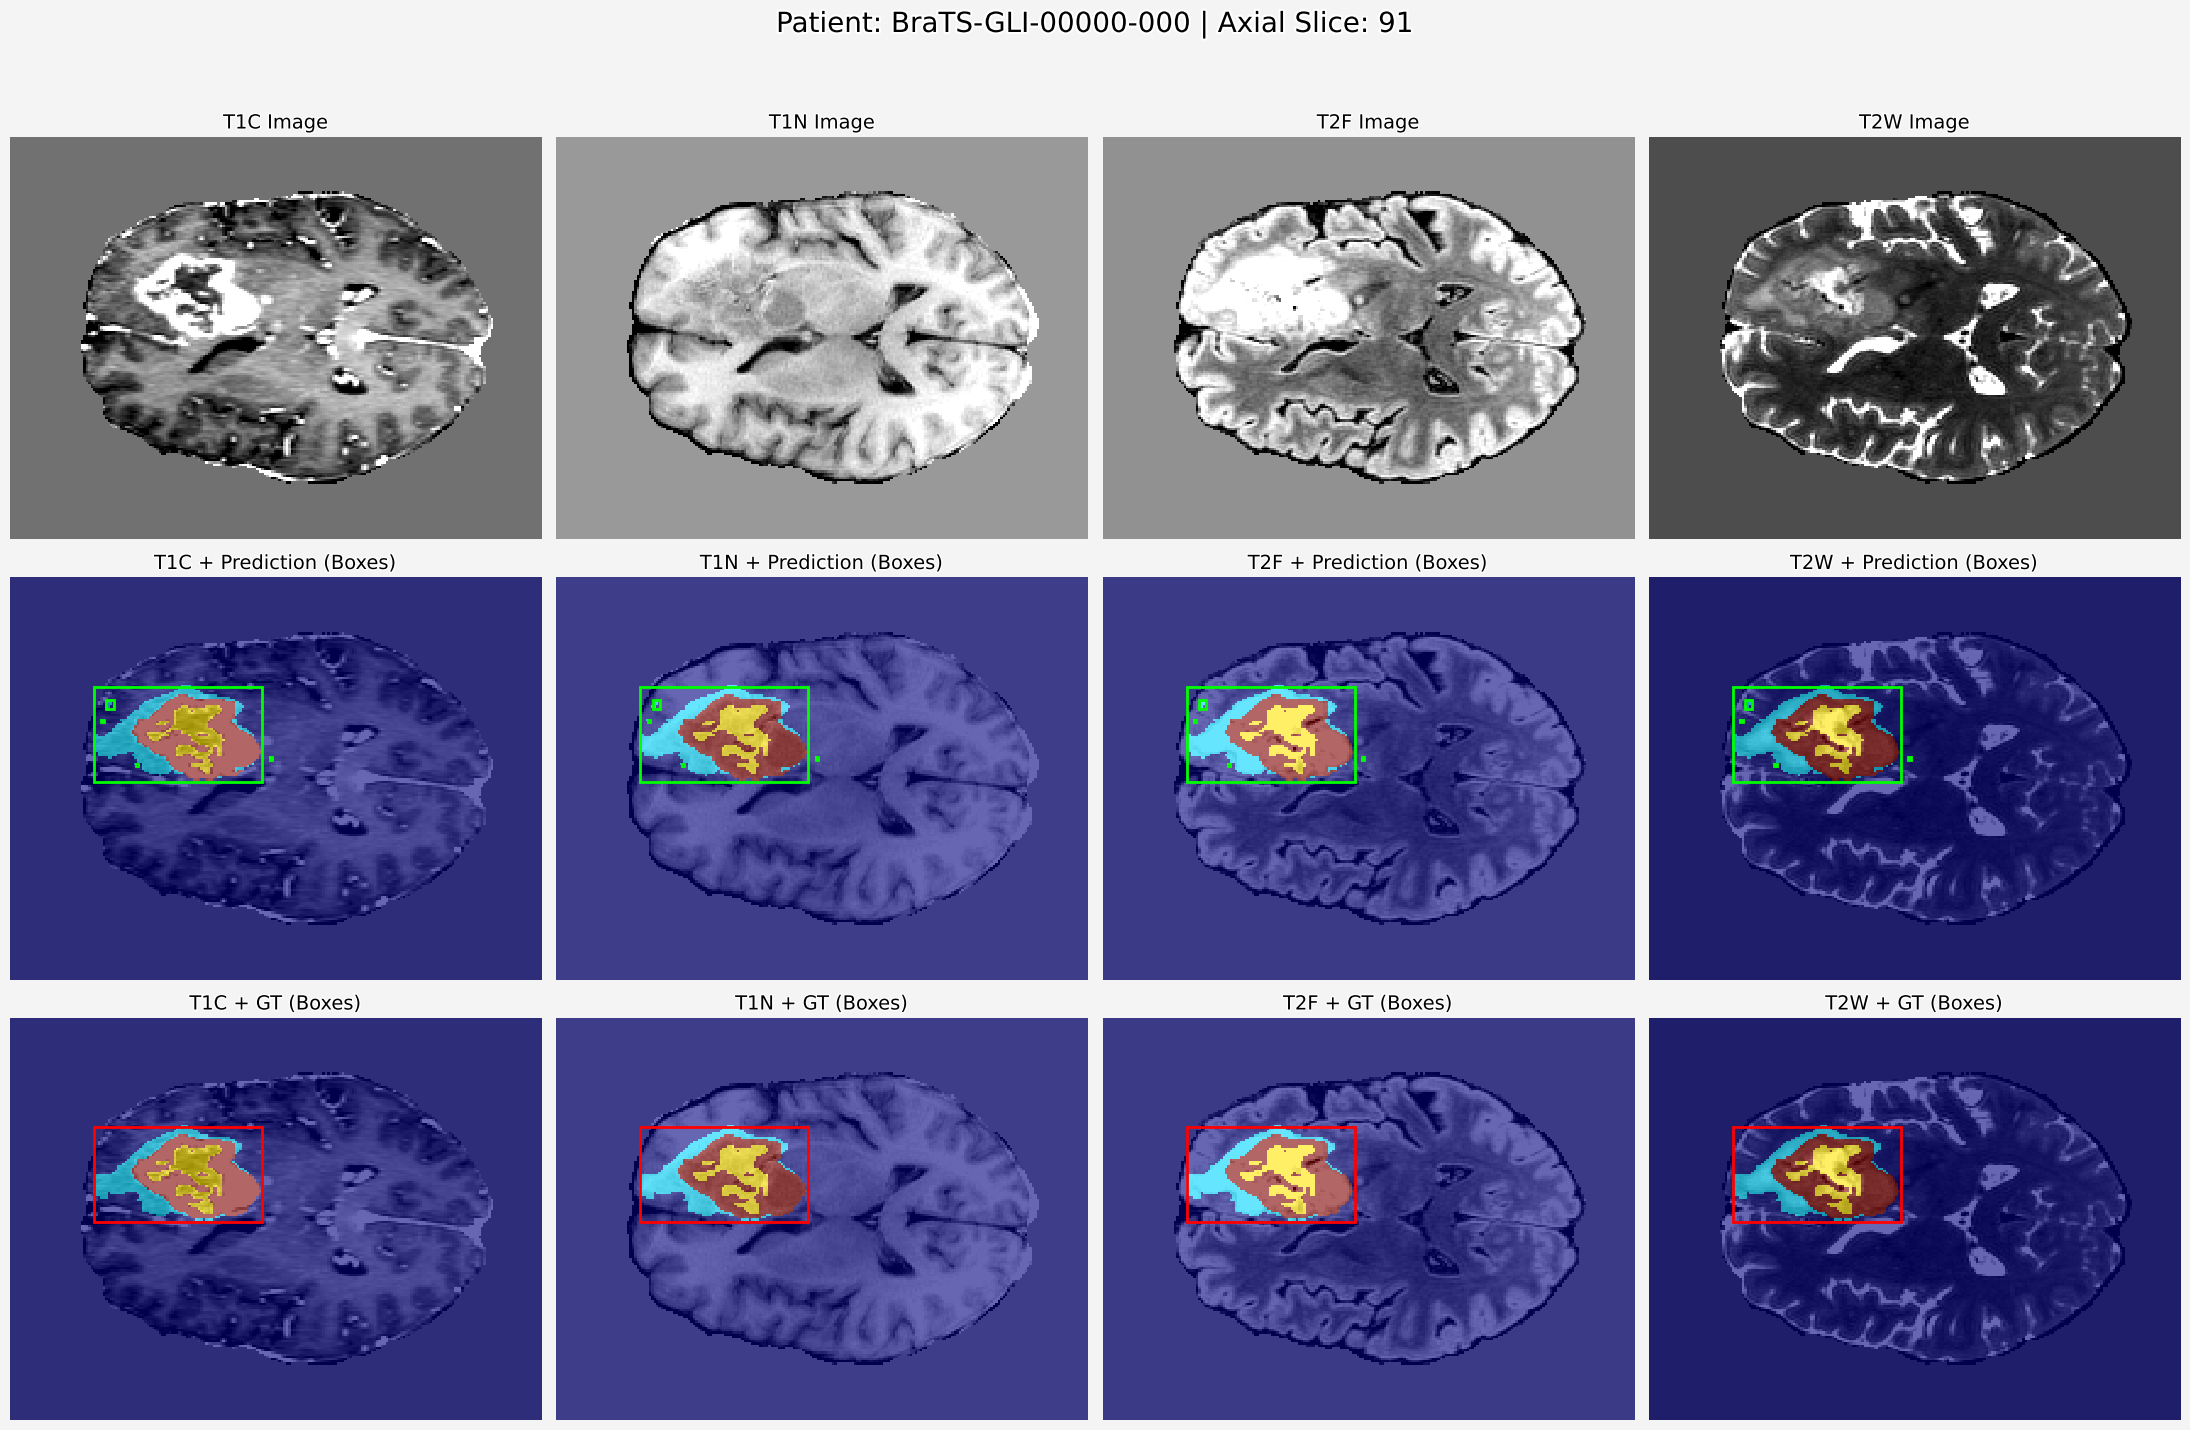

✅ Saved visualization with prediction & GT bounding boxes: output/BraTS-GLI-00000-000_pred_gt_boxes.png


In [ ]:
import os
import torch
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    NormalizeIntensityd, EnsureTyped, AsDiscrete, Activations, MapTransform
)
from monai.inferers import sliding_window_inference
from monai.data import Dataset, DataLoader, decollate_batch

# =========================
# Custom transform to convert labels into overlapping labels
# =========================
class ConvertToOverlapLabels(MapTransform):
    def __init__(self, keys):
        super().__init__(keys)

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            label = d[key]
            et_mask = (label == 3)
            tc_mask = (label == 1) | et_mask
            wt_mask = tc_mask | (label == 2)

            new_label = torch.zeros_like(label, dtype=torch.int64)
            new_label[wt_mask] = 1
            new_label[tc_mask] = 2
            new_label[et_mask] = 3

            d[key] = new_label
        return d

# =========================
# Define the test transforms
# =========================
test_transform = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    ConvertToOverlapLabels(keys=["label"]),
    EnsureTyped(keys=["image", "label"]),
])

# =========================
# Post-processing transforms
# =========================
post_trans = Compose([
    Activations(sigmoid=False, softmax=True),
    AsDiscrete(argmax=True, to_onehot=4),
])

# =========================
# Load model checkpoint
# =========================
model_ckpt_path = "/home/ali/R_and_D/BTS/Data/Brats2025_dataset/model/best_2024_model.ckpt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

net = Net.load_from_checkpoint(model_ckpt_path)
model = net._model.to(device)
model.eval()

# =========================
# Create test data dictionary
# =========================
def create_test_data(patient_dir):
    patient_id = os.path.basename(patient_dir)
    expected_files = {
        "t1c": f"{patient_id}-t1c.nii.gz",
        "t1n": f"{patient_id}-t1n.nii.gz",
        "t2f": f"{patient_id}-t2f.nii.gz",
        "t2w": f"{patient_id}-t2w.nii.gz",
        "seg": f"{patient_id}-seg.nii.gz"
    }

    files = {}
    for key, fname in expected_files.items():
        fpath = os.path.join(patient_dir, fname)
        if os.path.exists(fpath):
            files[key] = fpath
        else:
            if key != "seg":  # seg might be missing in test set
                raise FileNotFoundError(f"Missing required modality: {fpath}")

    return [{
        "image": [files["t1c"], files["t1n"], files["t2f"], files["t2w"]],
        "label": files.get("seg", None)
    }]

# =========================
# Inference function
# =========================
def infer_patient(patient_dir, output_dir="output"):
    test_files = create_test_data(patient_dir)
    test_ds = Dataset(data=test_files, transform=test_transform)
    test_loader = DataLoader(test_ds, batch_size=1, num_workers=1)
    os.makedirs(output_dir, exist_ok=True)

    pred_seg = None
    with torch.no_grad():
        for test_data in test_loader:
            patient_id = os.path.basename(patient_dir)
            test_images = test_data["image"].to(device)

            roi_size = (96, 96, 96)
            sw_batch_size = 4
            test_outputs = sliding_window_inference(test_images, roi_size, sw_batch_size, model)
            test_outputs = [post_trans(i) for i in decollate_batch(test_outputs)]
            test_outputs = test_outputs[0].cpu().numpy()
            pred_seg = np.argmax(test_outputs, axis=0).astype(np.uint8)

            original_image = test_data["image"][0].cpu().numpy()
            affine = nib.load(test_files[0]["image"][0]).affine

            # Save modalities
            mod_mapping = {0: "t1c", 1: "t1n", 2: "t2f", 3: "t2w"}
            for i, mod_name in mod_mapping.items():
                mod_img = nib.Nifti1Image(original_image[i], affine)
                nib.save(mod_img, os.path.join(output_dir, f"{patient_id}-{mod_name}.nii.gz"))

            # Save prediction
            pred_img = nib.Nifti1Image(pred_seg, affine)
            nib.save(pred_img, os.path.join(output_dir, f"{patient_id}_pred_seg.nii.gz"))
            print(f"✅ Saved prediction for {patient_id} in {output_dir}")

            # Save ground truth
            if "label" in test_data and test_data["label"] is not None:
                label_tensor = test_data["label"]
                label_data = label_tensor.cpu().numpy()[0].astype(np.uint8)
                label_img = nib.Nifti1Image(label_data, affine)
                nib.save(label_img, os.path.join(output_dir, f"{patient_id}_gt_seg.nii.gz"))
    return pred_seg

# =========================
# Visualization function
# =========================
def visualize_slices(patient_dir, output_dir="output"):
    import matplotlib.colors as colors
    from scipy.ndimage import label, find_objects
    import matplotlib.patches as patches

    patient_id = os.path.basename(patient_dir)
    modalities = ["t1c", "t1n", "t2f", "t2w"]
    images = {}

    def normalize_image(img):
        img = np.clip(img, np.percentile(img, 1), np.percentile(img, 99))
        img = (img - img.min()) / (img.max() - img.min() + 1e-5)
        return img

    # === Load & squeeze all modalities ===
    for mod in modalities:
        img_path = os.path.join(output_dir, f"{patient_id}-{mod}.nii.gz")
        img = nib.load(img_path).get_fdata()
        if img.ndim == 4 and img.shape[0] == 1:
            img = np.squeeze(img, axis=0)
        images[mod] = normalize_image(img)

    # === Load prediction ===
    pred_path = os.path.join(output_dir, f"{patient_id}_pred_seg.nii.gz")
    pred = nib.load(pred_path).get_fdata()
    if pred.ndim == 4 and pred.shape[0] == 1:
        pred = np.squeeze(pred, axis=0)

    # === Load ground truth (if exists) ===
    gt = None
    gt_path = os.path.join(output_dir, f"{patient_id}_gt_seg.nii.gz")
    if os.path.exists(gt_path):
        gt = nib.load(gt_path).get_fdata()
        if gt.ndim == 4 and gt.shape[0] == 1:
            gt = np.squeeze(gt, axis=0)

    slice_idx = images["t1c"].shape[2] // 2

    # === Create subplot grid ===
    n_rows = 3 if gt is not None else 2
    fig, axes = plt.subplots(n_rows, 4, figsize=(22, 15 if gt is not None else 11), facecolor="#f4f4f4")
    axes = axes.ravel()

    def styled_title(ax, title):
        txt = ax.set_title(title, fontsize=14, color='black')
        txt.set_path_effects([path_effects.Stroke(linewidth=2, foreground='white'),
                              path_effects.Normal()])

    # === Helper: draw bounding boxes ===
    def draw_bounding_boxes(ax, seg_img, color='lime'):
        labeled, num_features = label(seg_img > 0)
        boxes = find_objects(labeled)
        for i, slc in enumerate(boxes):
            if slc is None:
                continue
            y_min, y_max = slc[0].start, slc[0].stop
            x_min, x_max = slc[1].start, slc[1].stop
            rect = patches.Rectangle(
                (x_min, y_min),
                x_max - x_min,
                y_max - y_min,
                linewidth=2.0,
                edgecolor=color,
                facecolor='none'
            )
            ax.add_patch(rect)

    # === Plot slices ===
    for i, mod in enumerate(modalities):
        base_img = images[mod][:, :, slice_idx]

        # Row 1: raw image
        axes[i].imshow(base_img, cmap="gray", interpolation="nearest", aspect="auto")
        styled_title(axes[i], f"{mod.upper()} Image")
        axes[i].axis("off")

        # Row 2: prediction overlay + boxes
        seg_img = pred[:, :, slice_idx]
        axes[i + 4].imshow(base_img, cmap="gray", interpolation="nearest", aspect="auto")
        axes[i + 4].imshow(seg_img, alpha=0.6, cmap="jet", interpolation="nearest", aspect="auto")
        draw_bounding_boxes(axes[i + 4], seg_img, color='lime')  # 🟩 Pred boxes
        styled_title(axes[i + 4], f"{mod.upper()} + Prediction (Boxes)")
        axes[i + 4].axis("off")

        # Row 3: ground truth overlay + boxes
        if gt is not None:
            gt_img = gt[:, :, slice_idx]
            axes[i + 8].imshow(base_img, cmap="gray", interpolation="nearest", aspect="auto")
            axes[i + 8].imshow(gt_img, alpha=0.6, cmap="jet", interpolation="nearest", aspect="auto")
            draw_bounding_boxes(axes[i + 8], gt_img, color='red')  # 🟥 GT boxes
            styled_title(axes[i + 8], f"{mod.upper()} + GT (Boxes)")
            axes[i + 8].axis("off")

    suptitle = plt.suptitle(f"Patient: {patient_id} | Axial Slice: {slice_idx}", fontsize=20, color='black')
    suptitle.set_path_effects([path_effects.Stroke(linewidth=3, foreground='white'),
                               path_effects.Normal()])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    vis_path = os.path.join(output_dir, f"{patient_id}_pred_gt_boxes.png")
    plt.savefig(vis_path, dpi=300, facecolor=fig.get_facecolor())
    plt.show()
    plt.close()
    print(f"✅ Saved visualization with prediction & GT bounding boxes: {vis_path}")






# =========================
# Main Execution
# =========================
if __name__ == "__main__":
    patient_directory = "/home/ali/R_and_D/BTS/Data/Brats2025_dataset/BraTS2025-GLI-PRE-Challenge-TrainingData/BraTS-GLI-00000-000"
    pred_seg = infer_patient(patient_directory)
    visualize_slices(patient_directory)


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import json
from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.transforms import (
    AsDiscrete, Compose, LoadImaged, EnsureChannelFirstd,
    Orientationd, Spacingd, NormalizeIntensityd
)
from monai.inferers import sliding_window_inference
from monai.data import DataLoader, decollate_batch, load_decathlon_datalist
import monai.data
from monai.networks.nets import SwinUNETR
from monai.losses import DiceCELoss
import torch.nn as nn
import pytorch_lightning as pl
from sklearn.model_selection import train_test_split

# Define your Net class with all required imports
class ConvertToOverlapLabels:
    def __init__(self, keys):
        self.keys = keys

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            label = d[key]
            et_mask = (label == 3)
            tc_mask = (label == 1) | et_mask
            wt_mask = tc_mask | (label == 2)

            new_label = torch.zeros_like(label, dtype=torch.int64)
            new_label[wt_mask] = 1
            new_label[tc_mask] = 2
            new_label[et_mask] = 3

            d[key] = new_label
        return d

class Expert(nn.Module):
    def __init__(self, img_size=(96, 96, 96), in_channels=4, out_channels=4):
        super().__init__()
        self.model = SwinUNETR(
            img_size=img_size,
            in_channels=in_channels,
            out_channels=out_channels,
            feature_size=48,
            use_checkpoint=True,
        )

    def forward(self, x):
        return self.model(x)

class GatingNetwork(nn.Module):
    def __init__(self, num_experts=3, in_channels=4, hidden_dim=64):
        super().__init__()
        self.num_experts = num_experts
        self.feature_extractor = nn.Sequential(
            nn.Conv3d(in_channels, hidden_dim, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool3d(1),
            nn.Flatten()
        )
        self.gate = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_experts),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.gate(features)

class MoE_SWINUNETR(nn.Module):
    def __init__(self, num_experts=3, img_size=(96, 96, 96), in_channels=4, out_channels=4):
        super().__init__()
        self.num_experts = num_experts
        self.img_size = img_size
        self.experts = nn.ModuleList([Expert(img_size, in_channels, out_channels) for _ in range(num_experts)])
        self.gate = GatingNetwork(num_experts, in_channels)
        self.final_conv = nn.Conv3d(out_channels * num_experts, out_channels, kernel_size=1)

    def forward(self, x):
        gate_weights = self.gate(x)
        expert_outputs = []
        for i, expert in enumerate(self.experts):
            expert_out = expert(x)
            expert_outputs.append(expert_out * gate_weights[:, i].view(-1, 1, 1, 1, 1))
        combined = torch.cat(expert_outputs, dim=1)
        output = self.final_conv(combined)
        return output

class Net(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self._model = MoE_SWINUNETR(num_experts=3, img_size=(96, 96, 96), in_channels=4, out_channels=4)
        self.loss_function = DiceCELoss(to_onehot_y=True, softmax=True)
        self.post_pred = AsDiscrete(argmax=True, to_onehot=4)
        self.post_label = AsDiscrete(to_onehot=4)
        self.dice_metric = DiceMetric(include_background=False, reduction="mean")
        self.dice_metric_batch = DiceMetric(include_background=False, reduction="mean_batch")
        self.check_val = 1
        self.best_val_dice = 0
        self.best_val_epoch = 0

    def forward(self, x):
        return self._model(x)

    def prepare_data(self):
        datasets = "/home/ali/R_and_D/BTS/Data/Brats2025_dataset/preprocessed_2025_dataset.json"
        datalist = load_decathlon_datalist(datasets, True, "training")
        _, val_files = train_test_split(datalist, test_size=0.1, random_state=42)
        self.val_files = val_files

    def val_dataloader(self):
        val_transform = Compose([
            LoadImaged(keys=["image", "label"]),
            EnsureChannelFirstd(keys=["image", "label"]),
            Orientationd(keys=["image", "label"], axcodes="RAS"),
            ConvertToOverlapLabels(keys=["label"]),
            Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
            NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
        ])
        val_ds = monai.data.Dataset(data=self.val_files, transform=val_transform)
        return DataLoader(val_ds, batch_size=2, shuffle=False, num_workers=4)


/home/ali/anaconda3/envs/DUT/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ali/anaconda3/envs/DUT/lib/python3.11/site-packages/google/protobuf/__init__.py:37: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA devices:", torch.cuda.device_count())
print("PyTorch:", torch.__version__, "| CUDA:", torch.version.cuda)

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"[{i}] {props.name} | {props.total_memory/1024**3:.2f} GB total")
        # Current free/used (approx, per allocator)
        free, total = torch.cuda.mem_get_info(i)
        print(f"     mem: {free/1024**3:.2f} GB free / {total/1024**3:.2f} GB total")


CUDA available: True
CUDA devices: 2
PyTorch: 2.9.0.dev20250719+cu128 | CUDA: 12.8
[0] NVIDIA GeForce RTX 5090 | 31.37 GB total
     mem: 5.72 GB free / 31.37 GB total
[1] NVIDIA GeForce RTX 5090 | 31.37 GB total
     mem: 2.80 GB free / 31.37 GB total
